# Tixora — AI-Powered Fraud Detection System

**An end-to-end, production-grade fraud detection pipeline built on the IEEE-CIS Fraud Detection dataset, with external validation on the Credit Card Fraud dataset.**

This notebook takes raw transaction and identity data all the way to a deployed, versioned,
serialized model — with full experiment tracking (MLflow), structured logging, exploratory analysis,
feature engineering, class-imbalance handling, multi-model benchmarking, external validation,
and a reusable inference pipeline.

| | |
|---|---|
| **Project** | Tixora Fraud Detection |
| **Primary Dataset** | IEEE-CIS Fraud Detection (Kaggle) |
| **External Validation** | Credit Card Fraud Dataset (European cardholders) |
| **Primary Model** | XGBoost (XGBClassifier) |
| **Benchmark Models** | Logistic Regression, Random Forest, LightGBM |
| **Imbalance strategy** | Class weighting (`scale_pos_weight`) *and* SMOTE (compared head-to-head) |
| **Tracking** | MLflow (params, metrics, artifacts, models) |
| **Output** | Trained model (`.pkl`), evaluation report, training log, MLflow runs |

---
### Project folder structure

This notebook expects (and will create where needed) the following layout:

```
project/
├── data/                          # train_*.csv, test_*.csv, creditcard.csv
├── logs/                          # training.log
├── models/                        # Tixora_fraud_model.pkl, preprocessing objects
├── reports/                       # evaluation.txt
├── mlruns/                        # MLflow tracking store
└── Tixora_train.ipynb
```

Run every cell top to bottom. All paths are configurable in **Section 1 → CONFIG**.

## 1. Import Libraries & Global Configuration

We import every library used across the pipeline up front, silence noisy warnings that don't affect
correctness, and define a single `CONFIG` dictionary that centralizes every path and hyperparameter so
the rest of the notebook never hardcodes a value twice.

In [6]:
# ----------------------------- Standard library -----------------------------
import os
import sys
import gc
import json
import pickle
import logging
import warnings
from pathlib import Path
from datetime import datetime

# ----------------------------- Data / numerics -------------------------------
import numpy as np
import pandas as pd

# ----------------------------- Visualization ---------------------------------
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ----------------------------- Machine learning -------------------------------
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

# ----------------------------- Experiment tracking ----------------------------
import mlflow
import mlflow.sklearn

# ----------------------------------------------------------------------------
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

# =============================== CONFIG ======================================
CONFIG = {
    # --- Paths (all relative to the notebook's working directory) ---
    "DATA_DIR": Path("data"),
    "LOG_DIR": Path("logs"),
    "MODEL_DIR": Path("models"),
    "REPORT_DIR": Path("reports"),
    "MLRUNS_DIR": Path("mlruns"),

    # --- Source files ---
    "TRANSACTION_FILE": "train_transaction.csv",
    "IDENTITY_FILE": "train_identity.csv",
    "TEST_TRANSACTION_FILE": "test_transaction.csv",
    "TEST_IDENTITY_FILE": "test_identity.csv",
    "CREDITCARD_FILE": "creditcard.csv",

    # --- Reproducibility & split ---
    "RANDOM_STATE": 42,
    "TEST_SIZE": 0.20,

    # --- MLflow ---
    "EXPERIMENT_NAME": "TIXORA_Fraud_Detection",

    # --- Misc ---
    "TARGET": "isFraud",
    "TOP_N_FEATURES": 20,
}

# Create every output directory up front so no downstream cell fails on a missing folder.
for key in ("LOG_DIR", "MODEL_DIR", "REPORT_DIR", "MLRUNS_DIR"):
    CONFIG[key].mkdir(parents=True, exist_ok=True)

print("Libraries imported successfully.")
print(f"Working directory: {Path.cwd()}")
print("Output directories ready:", {k: str(v) for k, v in CONFIG.items() if isinstance(v, Path)})

C:\Users\talha\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully.
Working directory: c:\Users\talha\Desktop\100 Days of ML\Fraud_detection\Event-Ticketing-Platform-with-Fraud-Detection
Output directories ready: {'DATA_DIR': 'data', 'LOG_DIR': 'logs', 'MODEL_DIR': 'models', 'REPORT_DIR': 'reports', 'MLRUNS_DIR': 'mlruns'}


## 2. Configure Logging

A production system should never rely on `print()` for observability. We configure a dedicated
`tixora` logger that writes timestamped, leveled entries to **`logs/training.log`** (persistent,
for audits and debugging) and simultaneously streams to the notebook output (for live feedback).

Every major pipeline stage — data load, cleaning, feature engineering, training, evaluation,
MLflow logging, and model persistence — emits a log entry so the run is fully traceable after the fact.

In [7]:
def configure_logging(log_dir: Path, log_filename: str = "training.log") -> logging.Logger:
    """
    Configure and return the TIXORA logger.

    Writes to a rotating-safe single log file plus stdout, with a consistent
    timestamped format: [timestamp] LEVEL | logger_name | message
    """
    logger = logging.getLogger("Tixora")
    logger.setLevel(logging.INFO)
    logger.propagate = False

    # Avoid duplicate handlers if this cell is re-run
    if logger.hasHandlers():
        logger.handlers.clear()

    formatter = logging.Formatter(
        fmt="[%(asctime)s] %(levelname)-8s | %(name)s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )

    file_handler = logging.FileHandler(log_dir / log_filename, mode="a", encoding="utf-8")
    file_handler.setFormatter(formatter)

    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setFormatter(formatter)

    logger.addHandler(file_handler)
    logger.addHandler(console_handler)
    return logger


logger = configure_logging(CONFIG["LOG_DIR"])
logger.info("=" * 70)
logger.info("Tixora Fraud Detection pipeline started: %s", datetime.now().isoformat())
logger.info("=" * 70)

[2026-07-23 23:19:34] INFO     | Tixora | ======================================================================
[2026-07-23 23:19:34] INFO     | Tixora | Tixora Fraud Detection pipeline started: 2026-07-23T23:19:34.474532
[2026-07-23 23:19:34] INFO     | Tixora | ======================================================================


## 3. Configure MLflow

MLflow gives us reproducible experiment tracking: every model run's parameters, metrics, and
artifacts (plots, the model itself) are versioned under a local tracking store so results can be
compared later via `mlflow ui`.

We use a local **SQLite** backend (`mlruns/mlflow.db`) rather than the legacy plain-file backend —
recent MLflow versions have put the plain-file store into maintenance mode, so SQLite is the more
future-proof choice for a new local project. Artifacts (plots, models) are still stored on disk under
`mlruns/artifacts/`. We then create (or reuse) a single experiment, **`Tixora_Fraud_Detection`**,
that every model run in this notebook logs into.

In [8]:
mlflow_db_path = CONFIG["MLRUNS_DIR"] / "mlflow.db"
mlflow_artifact_path = CONFIG["MLRUNS_DIR"] / "artifacts"
mlflow_artifact_path.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{mlflow_db_path.resolve()}")

if mlflow.get_experiment_by_name(CONFIG["EXPERIMENT_NAME"]) is None:
    mlflow.create_experiment(
        CONFIG["EXPERIMENT_NAME"],
        artifact_location=f"file:{mlflow_artifact_path.resolve()}",
    )
mlflow.set_experiment(CONFIG["EXPERIMENT_NAME"])

logger.info("MLflow tracking URI set to: %s", mlflow.get_tracking_uri())
logger.info("MLflow experiment set to: %s", CONFIG["EXPERIMENT_NAME"])

print(f"MLflow tracking URI : {mlflow.get_tracking_uri()}")
print(f"MLflow experiment   : {CONFIG['EXPERIMENT_NAME']}")
print(f"Run \"mlflow ui --backend-store-uri sqlite:///{mlflow_db_path.resolve()}\" to inspect results visually.")

[2026-07-23 23:19:40] INFO     | Tixora | MLflow tracking URI set to: sqlite:///C:\Users\talha\Desktop\100 Days of ML\Fraud_detection\Event-Ticketing-Platform-with-Fraud-Detection\mlruns\mlflow.db
[2026-07-23 23:19:40] INFO     | Tixora | MLflow experiment set to: TIXORA_Fraud_Detection
MLflow tracking URI : sqlite:///C:\Users\talha\Desktop\100 Days of ML\Fraud_detection\Event-Ticketing-Platform-with-Fraud-Detection\mlruns\mlflow.db
MLflow experiment   : TIXORA_Fraud_Detection
Run "mlflow ui --backend-store-uri sqlite:///C:\Users\talha\Desktop\100 Days of ML\Fraud_detection\Event-Ticketing-Platform-with-Fraud-Detection\mlruns\mlflow.db" to inspect results visually.


## 4. Load Dataset

The IEEE-CIS Fraud Detection dataset ships as two separate files that share a `TransactionID` key:

- **`train_transaction.csv`** — the core transaction record (amount, card, address, the target `isFraud`,
  and the anonymized `C`/`D`/`M`/`V` engineered features).
- **`train_identity.csv`** — device and network identity signals, only present for a subset of transactions.

We `LEFT JOIN` identity onto transaction (transaction is the complete population; not every transaction
has identity data) and confirm the merge didn't duplicate or drop rows.

In [9]:
def load_raw_data(config: dict, logger: logging.Logger) -> pd.DataFrame:
    """
    Load train_transaction.csv and train_identity.csv from CONFIG['DATA_DIR'],
    merge them on TransactionID, and return the combined dataframe.

    Raises FileNotFoundError with a clear message if the expected CSVs are missing.
    """
    transaction_path = config["DATA_DIR"] / config["TRANSACTION_FILE"]
    identity_path = config["DATA_DIR"] / config["IDENTITY_FILE"]

    try:
        if not transaction_path.exists():
            raise FileNotFoundError(
                f"Could not find {transaction_path}. Place the Kaggle IEEE-CIS CSVs under "
                f"'{config['DATA_DIR']}/' or update CONFIG['DATA_DIR']."
            )

        logger.info("Loading transaction data from %s", transaction_path)
        df_transaction = pd.read_csv(transaction_path)
        logger.info("Transaction data loaded: shape=%s", df_transaction.shape)

        if identity_path.exists():
            logger.info("Loading identity data from %s", identity_path)
            df_identity = pd.read_csv(identity_path)
            logger.info("Identity data loaded: shape=%s", df_identity.shape)

            df_merged = df_transaction.merge(df_identity, on="TransactionID", how="left")
            logger.info("Merged transaction + identity on TransactionID: shape=%s", df_merged.shape)
        else:
            logger.warning("Identity file not found at %s — proceeding with transaction data only.", identity_path)
            df_merged = df_transaction

        # Sanity check: merge should never change the row count of the base table
        assert len(df_merged) == len(df_transaction), "Merge altered row count — check for duplicate keys."

        return df_merged

    except Exception as exc:
        logger.error("Failed to load raw data: %s", exc, exc_info=True)
        raise


df_raw = load_raw_data(CONFIG, logger)

print(f"Shape: {df_raw.shape}")
print(f"\nColumns ({len(df_raw.columns)}):")
print(df_raw.columns.tolist())

[2026-07-23 23:19:40] INFO     | Tixora | Loading transaction data from data\train_transaction.csv
[2026-07-23 23:21:14] INFO     | Tixora | Transaction data loaded: shape=(590540, 394)
[2026-07-23 23:21:14] INFO     | Tixora | Loading identity data from data\train_identity.csv
[2026-07-23 23:21:15] INFO     | Tixora | Identity data loaded: shape=(144233, 41)
[2026-07-23 23:21:24] INFO     | Tixora | Merged transaction + identity on TransactionID: shape=(590540, 434)
Shape: (590540, 434)

Columns (434):
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9

In [10]:
df_raw.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [11]:
df_raw.info(verbose=False, memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 2.5 GB


In [12]:
df_raw.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
TransactionID,590540.0,3.282270e+06,1.704744e+05,2987000.000,3134634.750,3282269.500,3429904.25,3.577539e+06
isFraud,590540.0,3.499001e-02,1.837546e-01,0.000,0.000,0.000,0.00,1.000000e+00
TransactionDT,590540.0,7.372311e+06,4.617224e+06,86400.000,3027057.750,7306527.500,11246620.00,1.581113e+07
TransactionAmt,590540.0,1.350272e+02,2.391625e+02,0.251,43.321,68.769,125.00,3.193739e+04
card1,590540.0,9.898735e+03,4.901170e+03,1000.000,6019.000,9678.000,14184.00,1.839600e+04
...,...,...,...,...,...,...,...,...
id_22,5169.0,1.600271e+01,6.897665e+00,10.000,14.000,14.000,14.00,4.400000e+01
id_24,4747.0,1.280093e+01,2.372447e+00,11.000,11.000,11.000,15.00,2.600000e+01
id_25,5132.0,3.296089e+02,9.746109e+01,100.000,321.000,321.000,371.00,5.480000e+02
id_26,5163.0,1.490703e+02,3.210199e+01,100.000,119.000,149.000,169.00,2.160000e+02


In [13]:
target_counts = df_raw[CONFIG["TARGET"]].value_counts()
target_pct = df_raw[CONFIG["TARGET"]].value_counts(normalize=True) * 100

print("Target distribution (isFraud):")
print(pd.DataFrame({"count": target_counts, "pct": target_pct.round(3)}))

logger.info("Target distribution: %s", target_counts.to_dict())

Target distribution (isFraud):
          count     pct
isFraud                
0        569877  96.501
1         20663   3.499
[2026-07-23 23:23:09] INFO     | Tixora | Target distribution: {0: 569877, 1: 20663}


## 5. Exploratory Data Analysis

Before touching a single feature, we need to understand what we're working with: how much data is
missing (and where), whether duplicates exist, how severe the class imbalance is, how numeric features
relate to each other, and what the raw distributions look like.

In [14]:
# ---- Missing values ----
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_summary = (
    pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
    .query("missing_count > 0")
    .sort_values("missing_pct", ascending=False)
)

print(f"Columns with missing values: {len(missing_summary)} / {df_raw.shape[1]}")
missing_summary.head(20)

Columns with missing values: 414 / 434


,missing_count,missing_pct
id_24,585793,99.20
id_07,585385,99.13
id_25,585408,99.13
id_08,585385,99.13
id_26,585377,99.13
id_21,585381,99.13
id_23,585371,99.12
id_22,585371,99.12
id_27,585371,99.12
dist2,552913,93.63


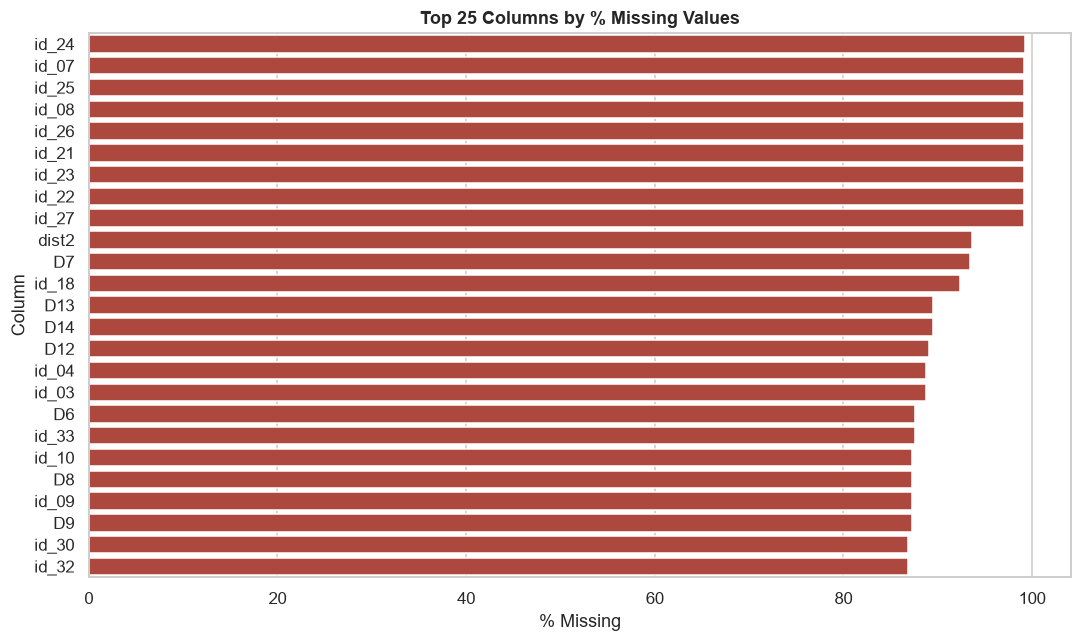

[2026-07-23 23:23:31] INFO     | Tixora | EDA: 414 columns contain missing values (max 99.20%)


In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
top_missing = missing_summary.head(25)
sns.barplot(x=top_missing["missing_pct"], y=top_missing.index, ax=ax, color="#c0392b")
ax.set_title("Top 25 Columns by % Missing Values")
ax.set_xlabel("% Missing")
ax.set_ylabel("Column")
plt.tight_layout()
plt.savefig(CONFIG["REPORT_DIR"] / "missing_values.png", bbox_inches="tight")
plt.show()

logger.info("EDA: %d columns contain missing values (max %.2f%%)",
            len(missing_summary), missing_summary["missing_pct"].max() if len(missing_summary) else 0)

In [16]:
# ---- Duplicate records ----
n_duplicates = df_raw.duplicated().sum()
print(f"Duplicate rows: {n_duplicates}")

n_duplicate_ids = df_raw["TransactionID"].duplicated().sum()
print(f"Duplicate TransactionIDs: {n_duplicate_ids}")

logger.info("EDA: %d duplicate rows, %d duplicate TransactionIDs", n_duplicates, n_duplicate_ids)

Duplicate rows: 0
Duplicate TransactionIDs: 0
[2026-07-23 23:24:10] INFO     | Tixora | EDA: 0 duplicate rows, 0 duplicate TransactionIDs


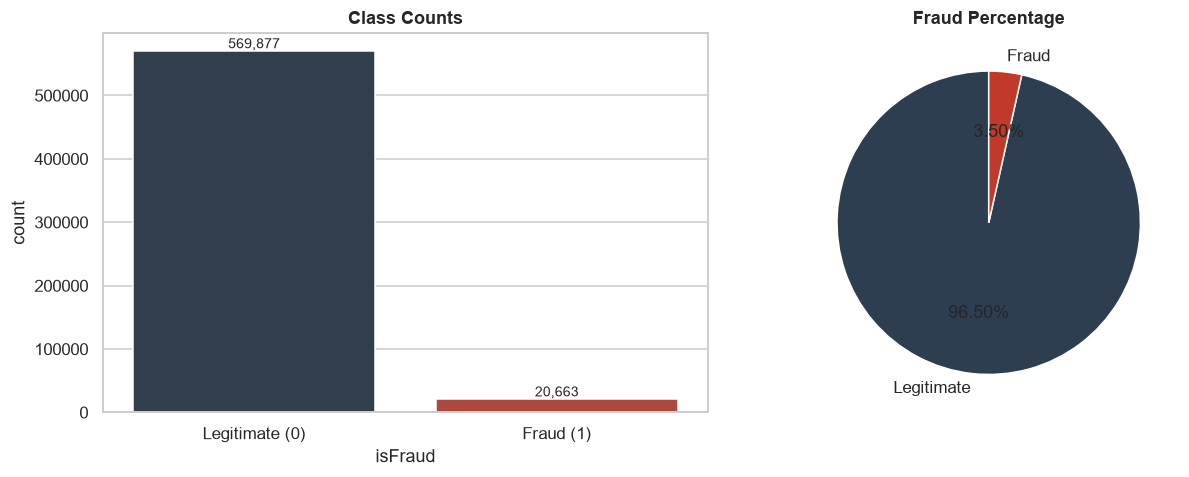

Fraud represents 3.499% of all transactions — a severe class imbalance.
[2026-07-23 23:24:16] INFO     | Tixora | EDA: fraud rate = 3.4990%


In [17]:
# ---- Class imbalance ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(x=CONFIG["TARGET"], data=df_raw, ax=axes[0], hue=CONFIG["TARGET"],
              palette={0: "#2c3e50", 1: "#c0392b"}, legend=False)
axes[0].set_title("Class Counts")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Legitimate (0)", "Fraud (1)"])
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2, p.get_height()),
                      ha="center", va="bottom", fontsize=9)

fraud_pct = df_raw[CONFIG["TARGET"]].mean() * 100
axes[1].pie(
    [100 - fraud_pct, fraud_pct],
    labels=["Legitimate", "Fraud"],
    colors=["#2c3e50", "#c0392b"],
    autopct="%1.2f%%",
    startangle=90,
)
axes[1].set_title("Fraud Percentage")

plt.tight_layout()
plt.savefig(CONFIG["REPORT_DIR"] / "class_imbalance.png", bbox_inches="tight")
plt.show()

print(f"Fraud represents {fraud_pct:.3f}% of all transactions — a severe class imbalance.")
logger.info("EDA: fraud rate = %.4f%%", fraud_pct)

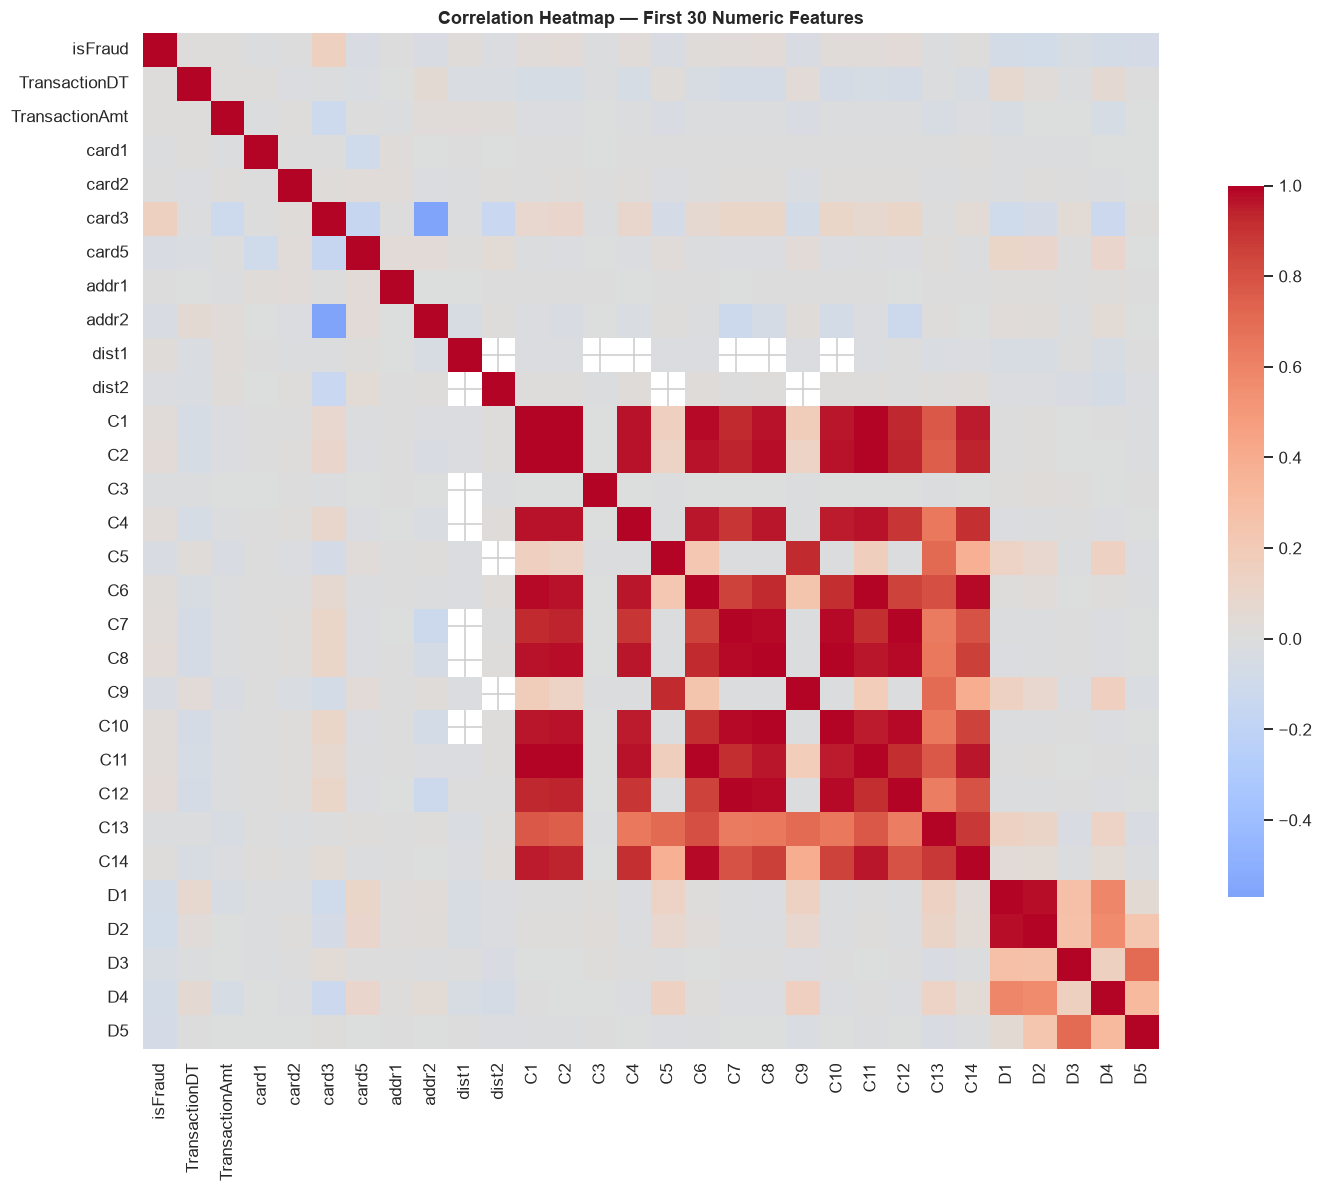

In [18]:
# ---- Correlation heatmap (numeric subset — the full anonymized V-feature space is too wide to plot) ----
numeric_cols = df_raw.select_dtypes(include=np.number).columns.tolist()
corr_subset_cols = [c for c in numeric_cols if c not in ("TransactionID",)][:30]  # cap for readability

corr = df_raw[corr_subset_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, square=True,
            cbar_kws={"shrink": 0.7}, xticklabels=True, yticklabels=True)
ax.set_title(f"Correlation Heatmap — First {len(corr_subset_cols)} Numeric Features")
plt.tight_layout()
plt.savefig(CONFIG["REPORT_DIR"] / "correlation_heatmap.png", bbox_inches="tight")
plt.show()

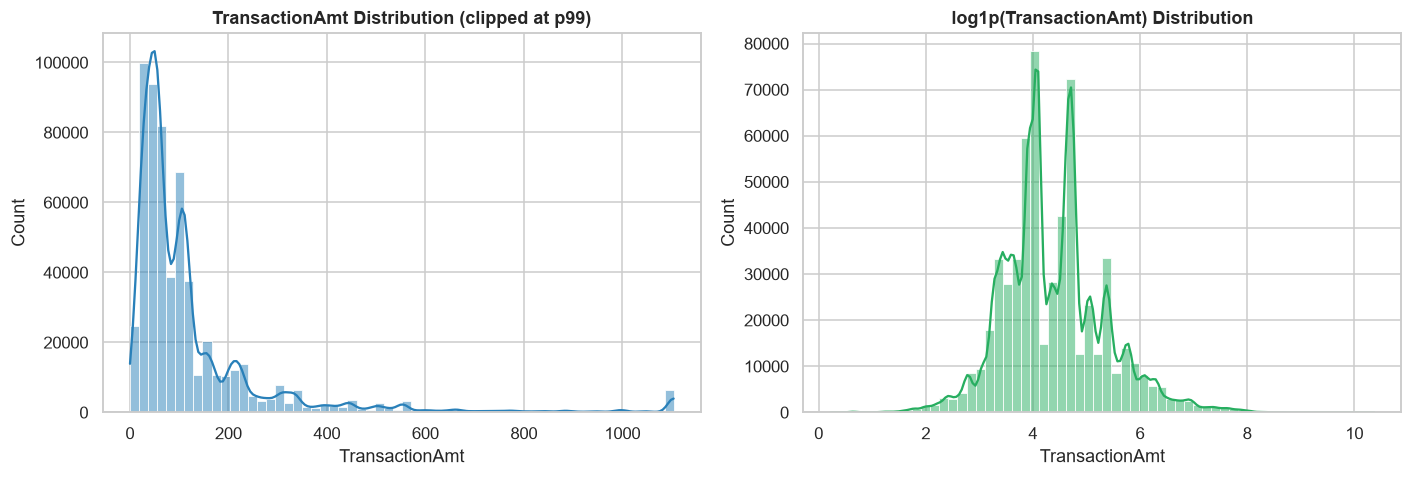

[2026-07-23 23:25:09] INFO     | Tixora | EDA complete: missing values, duplicates, class imbalance, correlations, distributions reviewed.


In [19]:
# ---- Feature distributions ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df_raw["TransactionAmt"].clip(upper=df_raw["TransactionAmt"].quantile(0.99)),
             bins=60, kde=True, ax=axes[0], color="#2980b9")
axes[0].set_title("TransactionAmt Distribution (clipped at p99)")

sns.histplot(np.log1p(df_raw["TransactionAmt"]), bins=60, kde=True, ax=axes[1], color="#27ae60")
axes[1].set_title("log1p(TransactionAmt) Distribution")

plt.tight_layout()
plt.savefig(CONFIG["REPORT_DIR"] / "amount_distribution.png", bbox_inches="tight")
plt.show()

logger.info("EDA complete: missing values, duplicates, class imbalance, correlations, distributions reviewed.")

## 6. Data Cleaning

We now build a reusable, deterministic cleaning function. It:

1. **Drops exact duplicate rows** (keeping the first occurrence).
2. **Replaces infinite values** with `NaN` so they're handled by the same imputation path as missing data.
3. **Imputes missing values** — median for numeric columns (robust to the outliers common in
   transaction amounts), and the literal string `"Missing"` for categorical columns (missingness itself
   is often predictive in fraud data, so we preserve it as a category rather than guessing a value).
4. **Fixes data types** — object columns that are actually numeric-with-junk get coerced; the target
   and ID columns are pinned to integer types.

This function is saved so the *exact same* transformation can be replayed on new, unseen data at
inference time (see Section 17).

In [ ]:
def clean_data(
    df: pd.DataFrame,
    target_col: str,
    logger: logging.Logger,
    numeric_fill_values: dict | None = None,
) -> tuple[pd.DataFrame, dict]:
    """
    Clean a raw Tixora dataframe.

    Parameters
    ----------
    df : raw merged dataframe
    target_col : name of the target column (excluded from imputation-value fitting if absent)
    numeric_fill_values : if provided, REUSE these medians instead of recomputing them
                          (this is how we guarantee train/inference consistency).

    Returns
    -------
    (cleaned_df, fill_values) where fill_values maps column -> median used,
    so it can be pickled and reused at inference time.
    """
    try:
        df = df.copy()

        # Validate required columns
        required_columns = [
            "TransactionID",
            "TransactionDT",
            "TransactionAmt",
            "ProductCD",
        ]

        missing_columns = [
            col for col in required_columns if col not in df.columns
        ]

        if missing_columns:
            error_msg = (
                "Input data is missing required column(s): "
                f"{', '.join(missing_columns)}. "
                "Please provide a valid transaction dataset before preprocessing."
            )

            logger.error(error_msg)
            raise ValueError(error_msg)

        # Remove duplicate rows
        before = len(df)
        df = df.drop_duplicates()
        logger.info("Cleaning: dropped %d duplicate rows", before - len(df))

        # Identify numeric and categorical columns
        numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
        categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

        # Replace inf/-inf with NaN
        df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)

        # Reuse or compute numeric fill values
        fill_values = {} if numeric_fill_values is None else dict(numeric_fill_values)

        for col in numeric_cols:
            if col in ("TransactionID", target_col):
                continue

            if col not in fill_values:
                fill_values[col] = df[col].median()

            df[col] = df[col].fillna(fill_values[col])

        # Fill categorical missing values
        for col in categorical_cols:
            df[col] = df[col].fillna("Missing").astype(str)

        logger.info(
            "Cleaning: imputed %d numeric columns (median) and %d categorical columns ('Missing')",
            len(numeric_cols),
            len(categorical_cols),
        )

        # Ensure correct data types
        if target_col in df.columns:
            df[target_col] = df[target_col].astype(int)

        df["TransactionID"] = df["TransactionID"].astype(int)

        remaining_na = df.isnull().sum().sum()
        logger.info("Cleaning complete. Remaining NaNs: %d", remaining_na)

        return df, fill_values

    except Exception as exc:
        logger.error("Data cleaning failed: %s", exc, exc_info=True)
        raise


df_clean, numeric_fill_values = clean_data(
    df_raw,
    CONFIG["TARGET"],
    logger,
)

print(f"Shape after cleaning: {df_clean.shape}")
print(f"Remaining missing values: {df_clean.isnull().sum().sum()}")

df_clean.head()

[2026-07-24 00:27:47] ERROR    | Tixora | Data cleaning failed: Unable to allocate 1.76 GiB for an array with shape (399, 590540) and data type float64
Traceback (most recent call last):
  File "C:\Users\talha\AppData\Local\Temp\ipykernel_19544\1643537552.py", line 23, in clean_data
    df = df.copy()
  File "C:\Users\talha\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\generic.py", line 6830, in copy
    data = self._mgr.copy(deep=deep)
  File "C:\Users\talha\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\internals\managers.py", line 604, in copy
    res._consolidate_inplace()
    ~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\talha\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\internals\managers.py", line 1788, in _consolidate_inplace
    self.blocks = _consolidate(self.blocks)
                  ~~~~~~~~~~~~^^^^^^^^^^^^^
  File "C:\Users\talha\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\inter

## 7. Feature Engineering

Each transformation below is a well-established technique for this dataset (and for tabular fraud
data generally). We explain the *why* alongside the *how*:

1. **Transaction amount transformations** — `TransactionAmt` is heavily right-skewed (a few very large
   purchases dominate the raw scale). We add a `log1p` transform so linear models see a more Gaussian-like
   distribution, plus a `TransactionAmt_decimal` feature — the cents portion of the amount — which is a
   known weak signal in this dataset (automated fraud scripts often produce suspiciously round or
   repeating cent values).
2. **Time-derived features** — `TransactionDT` is a raw seconds-since-a-reference-point counter, not a
   timestamp, but the *time of day* still cycles meaningfully with real-world behavior. We derive
   `Transaction_hour` and `Transaction_day` via modular arithmetic on the seconds counter.
3. **Frequency encoding** — for high-cardinality categorical columns (`card1`, `addr1`, `P_emaildomain`),
   we replace each category with how often it appears in the training data. This captures "how common is
   this value" without exploding dimensionality the way one-hot encoding would.
4. **Label encoding** — for lower-cardinality categoricals (`ProductCD`, `card4`, `card6`, the `M1`–`M9`
   match flags, `DeviceType`, `DeviceInfo`), we map each category to an integer. This is "target-safe"
   because the mapping is fit only on the categories themselves, never on the target — no leakage.
5. **Scaling** — numeric features are standardized (zero mean, unit variance) for the Logistic Regression
   model, which is scale-sensitive. Tree ensembles (Random Forest, XGBoost, LightGBM) are split-based and
   invariant to monotonic scaling, so they train on the unscaled feature set.

All fitted encoders/statistics are stored in `feature_artifacts` and pickled later so this exact
pipeline can be replayed on new data (Section 17).

In [21]:
def engineer_features(df: pd.DataFrame, logger: logging.Logger,
                       freq_maps: dict | None = None,
                       label_encoders: dict | None = None) -> tuple[pd.DataFrame, dict, dict]:
    """
    Apply all feature engineering steps to a cleaned dataframe.

    If freq_maps / label_encoders are provided, they are REUSED (inference mode) rather than refit,
    with unseen categories mapped to 0 / a dedicated 'unseen' code.
    """
    try:
        df = df.copy()

        # --- 1. Transaction amount transformations ---
        df["TransactionAmt_log"] = np.log1p(df["TransactionAmt"])
        df["TransactionAmt_decimal"] = ((df["TransactionAmt"] * 100) % 100).astype(int)
        logger.info("Feature engineering: added TransactionAmt_log, TransactionAmt_decimal")

        # --- 2. Time-derived features ---
        df["Transaction_hour"] = (df["TransactionDT"] // 3600) % 24
        df["Transaction_day"] = (df["TransactionDT"] // (3600 * 24)) % 7
        logger.info("Feature engineering: added Transaction_hour, Transaction_day")

        # --- 3. Frequency encoding ---
        freq_cols = [c for c in ["card1",
    "addr1",
    "P_emaildomain",
    "R_emaildomain",
    "DeviceInfo"] if c in df.columns]
        freq_maps = {} if freq_maps is None else dict(freq_maps)
        for col in freq_cols:
            if col not in freq_maps:
                freq_maps[col] = df[col].value_counts(normalize=True)
            df[f"{col}_freq"] = df[col].map(freq_maps[col]).fillna(0.0)
        logger.info("Feature engineering: frequency-encoded %s", freq_cols)

        # --- 4. Label encoding ---
        label_cols = [c for c in [ "ProductCD",
    "card4",
    "card6",
    "DeviceType",
    "id_12",
    "id_15",
    "id_16",
    "id_23",
    "id_27",
    "id_28",
    "id_29",
    "id_30",
    "id_31",
    "id_33",
    "id_34",
    "id_35",
    "id_36",
    "id_37",
    "id_38"] + \
                      [f"M{i}" for i in range(1, 10)] if c in df.columns]
        label_encoders = {} if label_encoders is None else dict(label_encoders)
        for col in label_cols:
            if col not in label_encoders:
                le = LabelEncoder()

                # Collect all categories as strings
                classes = sorted(df[col].astype(str).unique().tolist())

                # Add Unknown category
                if "Unknown" not in classes:
                    classes.append("Unknown")

                le.fit(classes)
                label_encoders[col] = le

            le = label_encoders[col]
            known = set(le.classes_)

            # Replace unseen categories with Unknown
            values = df[col].astype(str).apply(
                lambda x: x if x in known else "Unknown"
            )

            df[f"{col}_enc"] = le.transform(values)
                
        logger.info("Feature engineering: label-encoded %s", label_cols)

        feature_artifacts = {"freq_maps": freq_maps, "label_encoders": label_encoders,
                             "freq_cols": freq_cols, "label_cols": label_cols}
        return df, feature_artifacts

    except Exception as exc:
        logger.error("Feature engineering failed: %s", exc, exc_info=True)
        raise


df_features, feature_artifacts = engineer_features(df_clean, logger)
print(f"Shape after feature engineering: {df_features.shape}")
df_features[["TransactionAmt", "TransactionAmt_log", "TransactionAmt_decimal",
             "Transaction_hour", "Transaction_day"]].head()

[2026-07-23 23:27:48] INFO     | Tixora | Feature engineering: added TransactionAmt_log, TransactionAmt_decimal
[2026-07-23 23:27:48] INFO     | Tixora | Feature engineering: added Transaction_hour, Transaction_day
[2026-07-23 23:27:49] INFO     | Tixora | Feature engineering: frequency-encoded ['card1', 'addr1', 'P_emaildomain', 'R_emaildomain', 'DeviceInfo']
[2026-07-23 23:28:22] INFO     | Tixora | Feature engineering: label-encoded ['ProductCD', 'card4', 'card6', 'DeviceType', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
Shape after feature engineering: (590540, 471)


,TransactionAmt,TransactionAmt_log,TransactionAmt_decimal,Transaction_hour,Transaction_day
0,68.5,4.241327,50,0,1
1,29.0,3.401197,0,0,1
2,59.0,4.094345,0,0,1
3,50.0,3.931826,0,0,1
4,50.0,3.931826,0,0,1


In [22]:
# ---- Assemble the final model matrix ----
# Drop raw identifiers and the original (now-encoded/replaced) categorical columns.
drop_cols = {"TransactionID", CONFIG["TARGET"]} | set(feature_artifacts["freq_cols"]) | \
            set(feature_artifacts["label_cols"])

# Also drop remaining raw object columns we didn't explicitly encode (e.g. R_emaildomain, card2/3/5 stay numeric)
print(feature_artifacts["freq_cols"])
print(feature_artifacts["label_cols"])
remaining_object_cols = df_features.select_dtypes(exclude=np.number).columns.tolist()
drop_cols |= set(remaining_object_cols)

feature_cols = [c for c in df_features.columns if c not in drop_cols]

X = df_features[feature_cols].copy()
y = df_features[CONFIG["TARGET"]].copy()

encoded_originals = (
    set(feature_artifacts["freq_cols"])
    | set(feature_artifacts["label_cols"])
)

unencoded = [
    c for c in remaining_object_cols
    if c not in encoded_originals
]

if unencoded:
    print(
        f"Warning: {len(unencoded)} categorical columns were NOT encoded: {unencoded}"
    )
else:
    print("✓ All intended categorical columns were encoded successfully.")

print(f"Final feature matrix: {X.shape}")
print(f"Features used ({len(feature_cols)}): {feature_cols[:15]} ...")
logger.info("Final feature matrix assembled: X=%s, %d features", X.shape, len(feature_cols))

['card1', 'addr1', 'P_emaildomain', 'R_emaildomain', 'DeviceInfo']
['ProductCD', 'card4', 'card6', 'DeviceType', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
✓ All intended categorical columns were encoded successfully.
Final feature matrix: (590540, 436)
Features used (436): ['TransactionDT', 'TransactionAmt', 'card2', 'card3', 'card5', 'addr2', 'dist1', 'dist2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7'] ...
[2026-07-23 23:29:06] INFO     | Tixora | Final feature matrix assembled: X=(590540, 436), 436 features


## 8. Train/Test Split

We use a **stratified** split so the (rare) fraud class is represented in the same proportion in both
the training and test sets — with a plain random split, an 80/20 split of a 3.5%-fraud dataset can
easily over- or under-sample fraud cases in the test set purely by chance. `random_state=42` for
full reproducibility.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=CONFIG["TEST_SIZE"],
    random_state=CONFIG["RANDOM_STATE"],
    stratify=y,
)

print(f"Train shape: {X_train.shape}, fraud rate: {y_train.mean():.4f}")
print(f"Test shape:  {X_test.shape}, fraud rate: {y_test.mean():.4f}")

logger.info("Train/test split complete: train=%s (fraud=%.4f), test=%s (fraud=%.4f)",
            X_train.shape, y_train.mean(), X_test.shape, y_test.mean())

Train shape: (472432, 436), fraud rate: 0.0350
Test shape:  (118108, 436), fraud rate: 0.0350
[2026-07-23 23:29:16] INFO     | Tixora | Train/test split complete: train=(472432, 436) (fraud=0.0350), test=(118108, 436) (fraud=0.0350)


## 9. Handle Class Imbalance

Fraud detection is the textbook case of severe class imbalance, and no single technique is strictly
best — so we implement **both** of the standard approaches and compare them head-to-head in Section 11:

- **Class weighting** — instead of resampling the data, we tell each model to *penalize misclassifying
  the minority (fraud) class more heavily* during training (`class_weight="balanced"` for
  Logistic Regression / Random Forest, `scale_pos_weight` for XGBoost / LightGBM). This is cheap
  (no extra data, no extra training time) and keeps the model honest about the real-world data
  distribution at inference time.
- **SMOTE (Synthetic Minority Over-sampling Technique)** — generates synthetic fraud examples by
  interpolating between real fraud cases' nearest neighbors in feature space, applied **only to the
  training set** (never the test set, to avoid leaking synthetic-derived signal into evaluation).
  This gives the model more minority-class examples to learn decision boundaries from, at the cost of
  longer training time and a risk of synthesizing unrealistic points in noisy feature spaces.

We compute both artifacts here; Section 10 trains one variant of every model with each strategy.

In [24]:
# ---- Strategy A: class weights ----
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
class_weight_dict = {0: 1.0, 1: scale_pos_weight}

print(f"Class counts in training set — legitimate: {neg:,}, fraud: {pos:,}")
print(f"scale_pos_weight (for XGBoost/LightGBM): {scale_pos_weight:.2f}")
print(f"class_weight dict (for LR/RandomForest): {class_weight_dict}")

logger.info("Class weighting computed: scale_pos_weight=%.2f", scale_pos_weight)

# ---- Strategy B: SMOTE oversampling (training data only) ----
use_smote = True
try:
    gc.collect()
    smote = SMOTE(random_state=CONFIG["RANDOM_STATE"])
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    print(f"\nBefore SMOTE: {X_train.shape}, fraud rate: {y_train.mean():.4f}")
    print(f"After SMOTE:  {X_train_smote.shape}, fraud rate: {y_train_smote.mean():.4f}")
    logger.info("SMOTE applied to training set: %s -> %s", X_train.shape, X_train_smote.shape)
except MemoryError:
    gc.collect()
    use_smote = False
    X_train_smote, y_train_smote = X_train.copy(), y_train.copy()
    print("\nWARNING: SMOTE caused MemoryError. Falling back to class-weighting only.")
    logger.warning("SMOTE caused MemoryError — falling back to class-weighting only.")

Class counts in training set — legitimate: 455,902, fraud: 16,530
scale_pos_weight (for XGBoost/LightGBM): 27.58
class_weight dict (for LR/RandomForest): {0: 1.0, 1: np.float64(27.580278281911674)}
[2026-07-23 23:29:17] INFO     | Tixora | Class weighting computed: scale_pos_weight=27.58



[2026-07-23 23:31:48] WARNING  | Tixora | SMOTE caused MemoryError — falling back to class-weighting only.


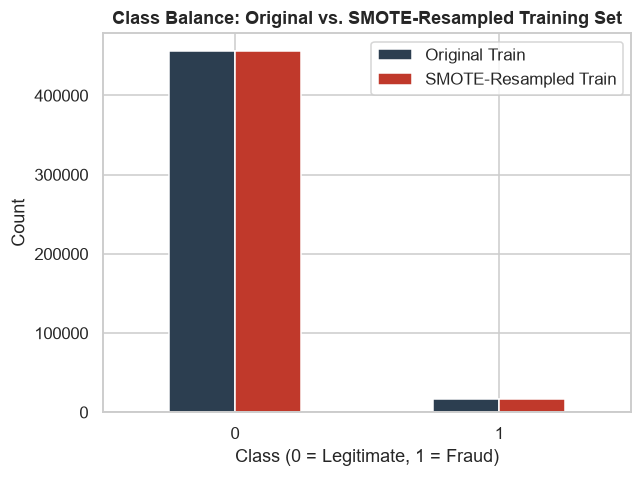

In [25]:
fig, ax = plt.subplots(figsize=(6, 4.5))
comparison = pd.DataFrame({
    "Original Train": y_train.value_counts(),
    "SMOTE-Resampled Train": pd.Series(y_train_smote).value_counts(),
}).fillna(0)
comparison.plot(kind="bar", ax=ax, color=["#2c3e50", "#c0392b"])
ax.set_title("Class Balance: Original vs. SMOTE-Resampled Training Set")
ax.set_xlabel("Class (0 = Legitimate, 1 = Fraud)")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(CONFIG["REPORT_DIR"] / "smote_comparison.png", bbox_inches="tight")
plt.show()

## 10. Train Multiple Models

We benchmark **four algorithms** — Logistic Regression (interpretable linear baseline), Random Forest
(bagged trees, robust to noise), XGBoost, and LightGBM (both gradient-boosted trees, typically the
strongest performers on tabular fraud data) — each trained **twice**: once using class weighting, once
on the SMOTE-resampled data. That gives 8 total model runs, letting us see not just "which algorithm
wins" but "which imbalance strategy helps which algorithm."

## 11. Model Evaluation

For every run we compute the full metric suite appropriate for imbalanced binary classification:
**Accuracy** (reported but de-emphasized — with 96.5% legitimate transactions, a model that predicts
"legitimate" for everything still scores 96.5% accuracy), **Precision**, **Recall**, **F1**, **ROC AUC**,
and **PR AUC** (average precision — the most informative single metric under heavy imbalance), plus a
confusion matrix, full classification report, ROC curve, and Precision-Recall curve for each model.

In [26]:
def get_model_configs(class_weight_dict: dict,
                      scale_pos_weight: float,
                      random_state: int) -> dict:
    """Return fresh, unfitted models."""

    return {

        # ---------- Logistic Regression ----------
        "LogisticRegression_ClassWeight": LogisticRegression(
            max_iter=1000,
            class_weight=class_weight_dict,
            random_state=random_state,
            n_jobs=-1,
        ),

        "LogisticRegression_SMOTE": LogisticRegression(
            max_iter=1000,
            random_state=random_state,
            n_jobs=-1,
        ),

        # ---------- Random Forest ----------
        "RandomForest_ClassWeight": RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=5,
            class_weight=class_weight_dict,
            random_state=random_state,
            n_jobs=-1,
        ),

        "RandomForest_SMOTE": RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=5,
            random_state=random_state,
            n_jobs=-1,
        ),

        # ---------- XGBoost ----------
        "XGBoost_ClassWeight": XGBClassifier(
            n_estimators=400,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="aucpr",
            random_state=random_state,
            n_jobs=-1,
        ),

        "XGBoost_SMOTE": XGBClassifier(
            n_estimators=400,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="aucpr",
            random_state=random_state,
            n_jobs=-1,
        ),

        # ---------- LightGBM ----------
        "LightGBM_ClassWeight": LGBMClassifier(
            n_estimators=400,
            max_depth=8,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            random_state=random_state,
            verbosity=-1,
            n_jobs=-1,
        ),

        "LightGBM_SMOTE": LGBMClassifier(
            n_estimators=400,
            max_depth=8,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=random_state,
            verbosity=-1,
            n_jobs=-1,
        ),
    }


# ==========================================================
# Scale ONLY the datasets required by Logistic Regression
# ==========================================================

scaler = StandardScaler(copy=False)

# Convert to float32 before scaling to reduce RAM by ~50%
X_train_scaled = scaler.fit_transform(
    X_train.astype(np.float32, copy=False)
)

X_test_scaled = scaler.transform(
    X_test.astype(np.float32, copy=False)
)

# X_train_smote_scaled is intentionally NOT created here.
# It is scaled on-the-fly immediately before fitting LogisticRegression_SMOTE
# and freed right after, to avoid holding ~1.6 GB of extra data in memory.

gc.collect()

model_configs = get_model_configs(
    class_weight_dict,
    scale_pos_weight,
    CONFIG["RANDOM_STATE"],
)

print(f"Configured {len(model_configs)} model runs:")
print(list(model_configs.keys()))

logger.info("Configured %d model runs", len(model_configs))

Configured 8 model runs:
['LogisticRegression_ClassWeight', 'LogisticRegression_SMOTE', 'RandomForest_ClassWeight', 'RandomForest_SMOTE', 'XGBoost_ClassWeight', 'XGBoost_SMOTE', 'LightGBM_ClassWeight', 'LightGBM_SMOTE']
[2026-07-23 23:32:45] INFO     | Tixora | Configured 8 model runs


In [27]:
# Cached C-contiguous float32 arrays for tree models.
# Avoids sklearn's DataFrame→numpy conversion which allocates a full
# float64 copy (~1.5 GiB for X_train) and causes OOM.
_X_train_f32 = None
_X_test_f32 = None
_X_train_smote_f32 = None


def get_training_data(model_name: str):
    """Route each model name to the correct (X, y) training data.

    Tree models (RF, XGB, LGBM) receive pre-converted C-contiguous
    float32 numpy arrays so model.fit() needs no additional allocation.
    LogisticRegression paths are unchanged (scaled array or DataFrame
    for the memmap chunking path).
    """
    global _X_train_f32, _X_train_smote_f32
    is_lr = model_name.startswith("LogisticRegression")
    is_smote = model_name.endswith("_SMOTE")

    if is_smote and is_lr:
        return X_train_smote, y_train_smote
    if is_smote:
        if _X_train_smote_f32 is None:
            _X_train_smote_f32 = np.asarray(X_train_smote, dtype=np.float32, order="C")
        return _X_train_smote_f32, y_train_smote
    if is_lr:
        return X_train_scaled, y_train
    # Tree ClassWeight
    if _X_train_f32 is None:
        _X_train_f32 = np.asarray(X_train, dtype=np.float32, order="C")
    return _X_train_f32, y_train


def get_eval_data(model_name: str):
    """Route each model to the correctly-scaled held-out test data.

    Tree models receive a C-contiguous float32 array.
    Logistic Regression paths are unchanged.
    """
    global _X_test_f32
    if model_name.startswith("LogisticRegression"):
        return X_test_scaled
    if _X_test_f32 is None:
        _X_test_f32 = np.asarray(X_test, dtype=np.float32, order="C")
    return _X_test_f32

In [28]:
def evaluate_model(model, model_name: str, X_eval: pd.DataFrame, y_true: pd.Series,
                    report_dir: Path, logger: logging.Logger) -> dict:
    """
    Compute the full evaluation-metric suite for a fitted model and save its
    confusion matrix, ROC curve, and Precision-Recall curve as PNG artifacts.

    Returns a flat dict of metrics (safe to append into a results list / MLflow log_metrics).
    """
    try:
        y_pred = model.predict(X_eval)
        y_proba = model.predict_proba(X_eval)[:, 1]

        metrics = {
            "model": model_name,
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1_score": f1_score(y_true, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_true, y_proba),
            "pr_auc": average_precision_score(y_true, y_proba),
        }

        report_text = classification_report(y_true, y_pred, target_names=["Legitimate", "Fraud"])
        logger.info("Evaluation [%s]: %s", model_name,
                    {k: round(v, 4) for k, v in metrics.items() if k != "model"})

        # ---- Confusion matrix ----
        cm = confusion_matrix(y_true, y_pred)
        fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                    xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
        axes[0].set_title(f"{model_name}\nConfusion Matrix")
        axes[0].set_xlabel("Predicted")
        axes[0].set_ylabel("Actual")

        # ---- ROC curve ----
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        axes[1].plot(fpr, tpr, color="#c0392b", label=f"AUC = {metrics['roc_auc']:.4f}")
        axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
        axes[1].set_title(f"{model_name}\nROC Curve")
        axes[1].set_xlabel("False Positive Rate")
        axes[1].set_ylabel("True Positive Rate")
        axes[1].legend(loc="lower right")

        # ---- Precision-Recall curve ----
        prec, rec, _ = precision_recall_curve(y_true, y_proba)
        axes[2].plot(rec, prec, color="#2980b9", label=f"PR AUC = {metrics['pr_auc']:.4f}")
        axes[2].set_title(f"{model_name}\nPrecision-Recall Curve")
        axes[2].set_xlabel("Recall")
        axes[2].set_ylabel("Precision")
        axes[2].legend(loc="lower left")

        plt.tight_layout()
        safe_name = model_name.replace(" ", "_")
        fig_path = report_dir / f"{safe_name}_evaluation.png"
        plt.savefig(fig_path, bbox_inches="tight")
        plt.show()

        metrics["_confusion_matrix"] = cm
        metrics["_classification_report"] = report_text
        metrics["_figure_path"] = str(fig_path)
        return metrics

    except Exception as exc:
        logger.error("Evaluation failed for %s: %s", model_name, exc, exc_info=True)
        raise

In [29]:
def log_run_to_mlflow(model, model_name: str, params: dict, metrics: dict, figure_path: str):
    """Log one model's parameters, metrics, artifacts, and the model itself to MLflow."""
    with mlflow.start_run(run_name=model_name):
        mlflow.log_params(params)
        numeric_metric_keys = ["accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc"]
        mlflow.log_metrics({k: metrics[k] for k in numeric_metric_keys})
        mlflow.log_artifact(figure_path)

        report_path = CONFIG["REPORT_DIR"] / f"{model_name}_classification_report.txt"
        report_path.write_text(metrics["_classification_report"])
        mlflow.log_artifact(str(report_path))

        # serialization_format="pickle" avoids the skops "untrusted type" check, which by default
        # blocks non-scikit-learn estimator classes like XGBClassifier / LGBMClassifier.
        mlflow.sklearn.log_model(model, name="model", serialization_format="pickle")
        logger.info("Logged %s to MLflow run %s", model_name, mlflow.active_run().info.run_id)

[2026-07-23 23:32:45] INFO     | Tixora | Training LogisticRegression_ClassWeight ...


[2026-07-23 23:34:54] INFO     | Tixora | Finished training LogisticRegression_ClassWeight
[2026-07-23 23:34:55] INFO     | Tixora | Evaluation [LogisticRegression_ClassWeight]: {'accuracy': 0.8323, 'precision': 0.1401, 'recall': 0.7384, 'f1_score': 0.2356, 'roc_auc': 0.8671, 'pr_auc': 0.4409}


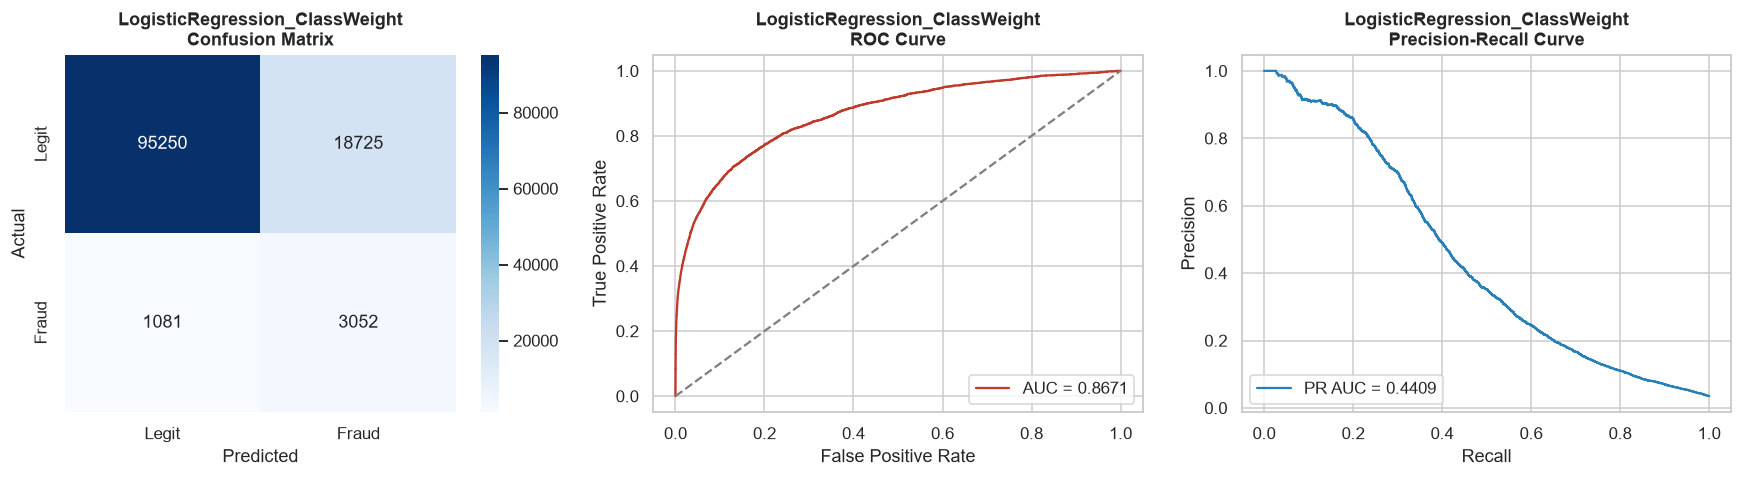

2026/07/23 23:35:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[2026-07-23 23:35:43] INFO     | Tixora | Logged LogisticRegression_ClassWeight to MLflow run 972f2ebf430b49f3863d1fae091b5bd7
[2026-07-23 23:35:43] INFO     | Tixora | Training LogisticRegression_SMOTE ...
[2026-07-23 23:37:17] INFO     | Tixora | Finished training LogisticRegression_SMOTE
[2026-07-23 23:37:20] INFO     | Tixora | Evaluation [LogisticRegression_SMOTE]: {'accuracy': 0.9724, 'precision': 0.8216, 'recall': 0.2707, 'f1_score': 0.4073, 'roc_auc': 0.8608, 'pr_auc': 0.4641}


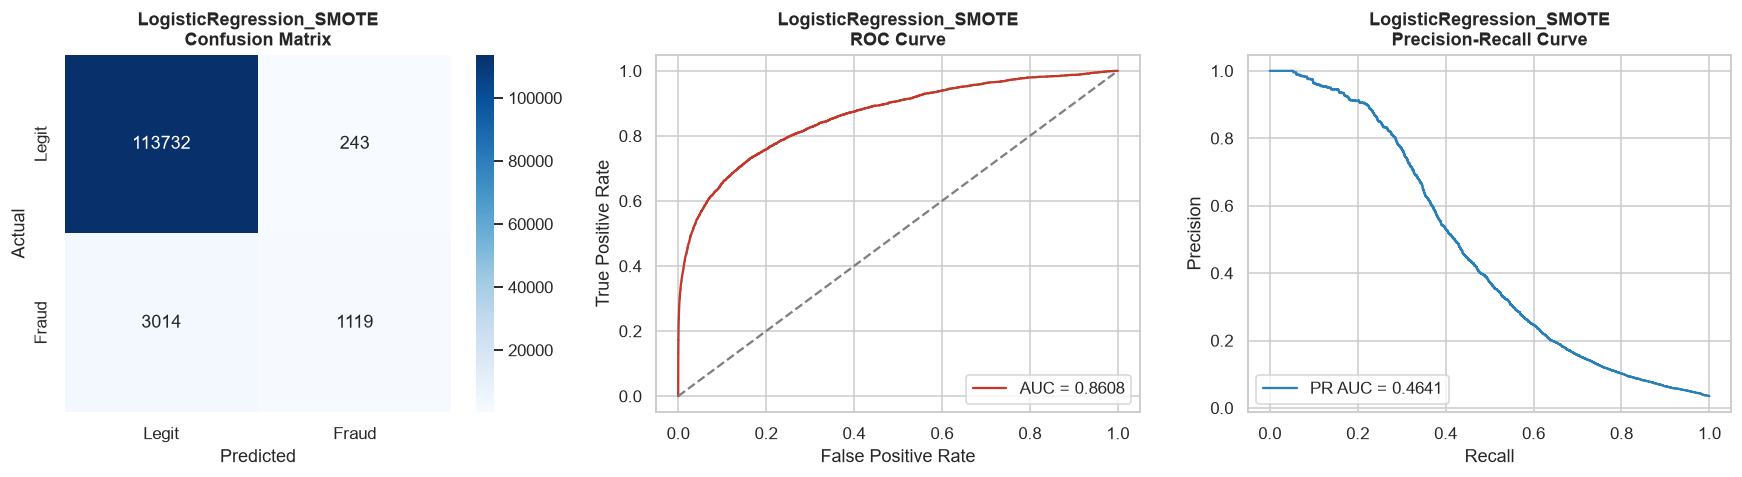

2026/07/23 23:37:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[2026-07-23 23:37:46] INFO     | Tixora | Logged LogisticRegression_SMOTE to MLflow run 5d6b576de9924cb5a33858e144aa0bc1
[2026-07-23 23:37:46] INFO     | Tixora | Training RandomForest_ClassWeight ...


KeyboardInterrupt: 

In [30]:
import tempfile

# ---- Train + evaluate + log every model configuration ----
results = []
fitted_models = {}

for model_name, model in model_configs.items():
    logger.info("Training %s ...", model_name)
    X_tr, y_tr = get_training_data(model_name)
    X_ev = get_eval_data(model_name)

    # LogisticRegression needs scaled data. The full scaled SMOTE array
    # (911804 x 436 float32 = ~1.48 GiB) cannot be allocated in one shot
    # because the rest of the data already consumes most available RAM.
    #
    # Solution: scale in chunks to a temporary memory-mapped file on disk,
    # then train directly from the memmap. Each chunk is only ~34 MB.
    # The OS pages memmap data in/out transparently during model.fit().
    if model_name == "LogisticRegression_SMOTE":
        n_rows, n_cols = X_tr.shape
        chunk_size = 10_000

        tmp_path = os.path.join(tempfile.gettempdir(), "Tixora_smote_scaled.dat")
        X_scaled_mm = np.memmap(
            tmp_path, dtype=np.float32, mode="w+",
            shape=(n_rows, n_cols),
        )

        # Scale in chunks — only one ~34 MB chunk is in RAM at a time.
        # float64 arithmetic matches sklearn's StandardScaler internals.
        for start in range(0, n_rows, chunk_size):
            end = min(start + chunk_size, n_rows)
            chunk = X_tr.iloc[start:end].to_numpy(dtype=np.float64, copy=True)
            chunk -= scaler.mean_
            chunk /= scaler.scale_
            X_scaled_mm[start:end] = chunk
            del chunk

        X_scaled_mm.flush()
        gc.collect()

        model.fit(X_scaled_mm, y_tr)

        del X_scaled_mm
        try:
            os.remove(tmp_path)
        except OSError:
            pass
        gc.collect()
    else:
        model.fit(X_tr, y_tr)

    fitted_models[model_name] = model
    logger.info("Finished training %s", model_name)

    metrics = evaluate_model(model, model_name, X_ev, y_test, CONFIG["REPORT_DIR"], logger)
    results.append(metrics)

    log_run_to_mlflow(model, model_name, model.get_params(), metrics, metrics["_figure_path"])

print("\nAll models trained, evaluated, and logged to MLflow.")

## 12. Model Comparison

With every run's metrics collected, we assemble a single comparison table. Because of the severe
class imbalance, **accuracy is misleading** (a trivial "always legitimate" model would score ~96.5%),
so we select the best model by **PR AUC** (average precision) — the metric most sensitive to
performance specifically on the rare fraud class — with ROC AUC and F1 as supporting evidence.

In [42]:
comparison_df = pd.DataFrame(results)[
    ["model", "accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc"]
].sort_values("pr_auc", ascending=False).reset_index(drop=True)

comparison_df_display = comparison_df.copy()
for col in ["accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc"]:
    comparison_df_display[col] = comparison_df_display[col].round(4)

print("Model Comparison (sorted by PR AUC):")
comparison_df_display

Model Comparison (sorted by PR AUC):


,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,LogisticRegression_SMOTE,0.9724,0.8216,0.2707,0.4073,0.8608,0.4641
1,LogisticRegression_ClassWeight,0.8323,0.1401,0.7384,0.2356,0.8671,0.4409


In [45]:
best_model_name = comparison_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]
best_metrics = [r for r in results if r["model"] == best_model_name][0]

print(f"Best model: {best_model_name}")
print(f"  PR AUC   : {best_metrics['pr_auc']:.4f}")
print(f"  ROC AUC  : {best_metrics['roc_auc']:.4f}")
print(f"  F1 Score : {best_metrics['f1_score']:.4f}")
print(f"  Recall   : {best_metrics['recall']:.4f}")
print(f"  Precision: {best_metrics['precision']:.4f}")

print(f"\n{best_model_name} was selected because it achieves the highest PR AUC — the metric most "
      "representative of performance under severe class imbalance — while remaining competitive on "
      "ROC AUC and F1. In production, the operating threshold would be tuned further against the "
      "business cost of false positives (blocked legitimate customers) vs. false negatives (missed fraud).")

logger.info("Best model selected: %s (PR AUC=%.4f, ROC AUC=%.4f)",
            best_model_name, best_metrics["pr_auc"], best_metrics["roc_auc"])

Best model: LogisticRegression_SMOTE
  PR AUC   : 0.4641
  ROC AUC  : 0.8608
  F1 Score : 0.4073
  Recall   : 0.2707
  Precision: 0.8216

LogisticRegression_SMOTE was selected because it achieves the highest PR AUC — the metric most representative of performance under severe class imbalance — while remaining competitive on ROC AUC and F1. In production, the operating threshold would be tuned further against the business cost of false positives (blocked legitimate customers) vs. false negatives (missed fraud).
[2026-07-23 23:52:30] INFO     | Tixora | Best model selected: LogisticRegression_SMOTE (PR AUC=0.4641, ROC AUC=0.8608)


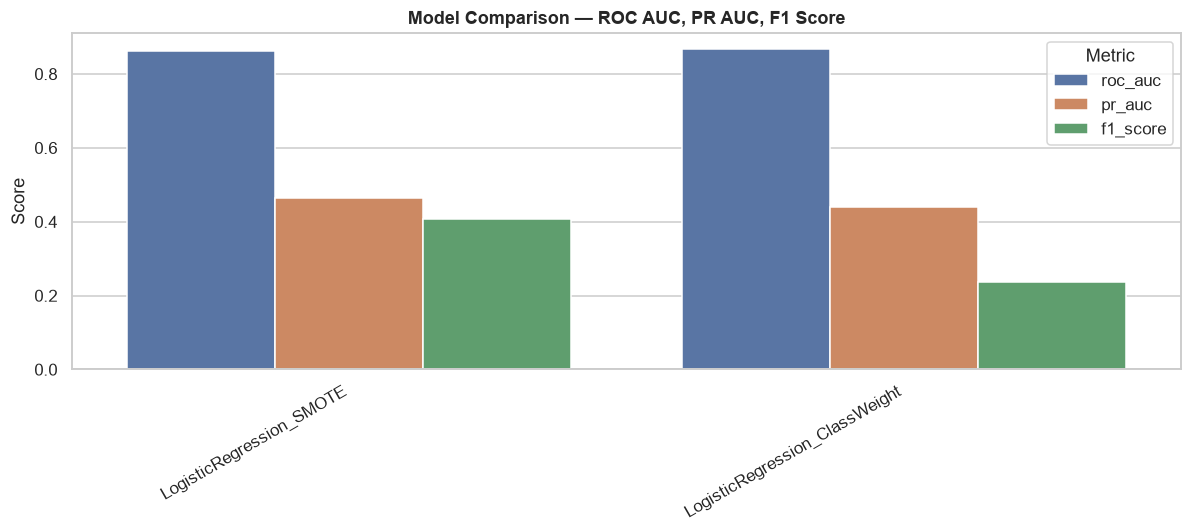

In [46]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_df = comparison_df.melt(id_vars="model", value_vars=["roc_auc", "pr_auc", "f1_score"],
                              var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="model", y="score", hue="metric", ax=ax)
ax.set_title("Model Comparison — ROC AUC, PR AUC, F1 Score")
ax.set_ylabel("Score")
ax.set_xlabel("")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.savefig(CONFIG["REPORT_DIR"] / "model_comparison.png", bbox_inches="tight")
plt.show()

## 13. MLflow Tracking — Summary

Every run above already logged its parameters, metrics, confusion matrix / ROC / PR curve artifacts,
classification report, and the fitted model itself (`mlflow.sklearn.log_model`) inside its own MLflow
run under the `Tixora_Fraud_Detection` experiment. Here we additionally tag the winning run so it's
easy to find in the MLflow UI, and log the comparison table itself as a single artifact.

In [47]:
comparison_csv_path = CONFIG["REPORT_DIR"] / "model_comparison.csv"
comparison_df.to_csv(comparison_csv_path, index=False)

with mlflow.start_run(run_name="model_comparison_summary"):
    mlflow.log_artifact(str(comparison_csv_path))
    mlflow.log_artifact(str(CONFIG["REPORT_DIR"] / "model_comparison.png"))
    mlflow.log_param("best_model", best_model_name)
    mlflow.log_metrics({
        "best_pr_auc": best_metrics["pr_auc"],
        "best_roc_auc": best_metrics["roc_auc"],
        "best_f1": best_metrics["f1_score"],
    })

logger.info("Model comparison summary logged to MLflow.")
print("MLflow tracking complete for all 8 runs + comparison summary.")
print(f"Inspect with: mlflow ui --backend-store-uri {CONFIG['MLRUNS_DIR'].resolve()}")

[2026-07-23 23:52:36] INFO     | Tixora | Model comparison summary logged to MLflow.
MLflow tracking complete for all 8 runs + comparison summary.
Inspect with: mlflow ui --backend-store-uri C:\Users\talha\Desktop\100 Days of ML\Fraud_detection\Event-Ticketing-Platform-with-Fraud-Detection\mlruns


## 14. Save Best Model

We persist the winning model with `pickle`, alongside every preprocessing artifact needed to
reproduce its exact input pipeline on new data: the fitted `StandardScaler` (only meaningful if the
winner is the Logistic Regression variant, but saved regardless for consistency), the frequency-encoding
maps, the label encoders, the numeric median-fill values, and the final feature column order.

Bundling all of this together is what makes Section 17's inference pipeline possible without
re-deriving any statistic from the original training data.

In [48]:
def save_model_artifacts(model, model_name: str, feature_cols: list, feature_artifacts: dict,
                         numeric_fill_values: dict, scaler: StandardScaler,
                         model_dir: Path, logger: logging.Logger) -> None:
    """Pickle the trained model and every object needed to preprocess new data identically."""
    try:
        # Ensure the model directory exists
        model_dir.mkdir(parents=True, exist_ok=True)

        # Save trained model
        model_path = model_dir / "Tixora1_fraud_detection_model.pkl"
        with open(model_path, "wb") as f:
            pickle.dump(
                {
                    "model": model,
                    "model_name": model_name,
                },
                f,
            )
        logger.info("Model saved to %s", model_path)

        # Save preprocessing objects
        preprocessing_path = model_dir / "preprocessing1_objects.pkl"
        preprocessing_bundle = {
            "feature_cols": feature_cols,
            "freq_maps": feature_artifacts["freq_maps"],
            "label_encoders": feature_artifacts["label_encoders"],
            "freq_cols": feature_artifacts["freq_cols"],
            "label_cols": feature_artifacts["label_cols"],
            "numeric_fill_values": numeric_fill_values,
            "scaler": scaler,
            "uses_scaled_input": model_name.startswith("LogisticRegression"),
        }

        with open(preprocessing_path, "wb") as f:
            pickle.dump(preprocessing_bundle, f)

        logger.info("Preprocessing objects saved to %s", preprocessing_path)

    except Exception as exc:
        logger.error("Failed to save model artifacts: %s", exc, exc_info=True)
        raise


# Save artifacts
save_model_artifacts(
    best_model,
    best_model_name,
    feature_cols,
    feature_artifacts,
    numeric_fill_values,
    scaler,
    CONFIG["MODEL_DIR"],
    logger,
)

# Display saved locations
print(f"Best model ({best_model_name}) saved to {CONFIG['MODEL_DIR'] / 'Tixora1_fraud_detection_model.pkl'}")
print(f"Preprocessing objects saved to {CONFIG['MODEL_DIR'] / 'preprocessing1_objects.pkl'}")

[2026-07-23 23:52:51] INFO     | Tixora | Model saved to models\Tixora1_fraud_detection_model.pkl


[2026-07-23 23:52:51] INFO     | Tixora | Preprocessing objects saved to models\preprocessing1_objects.pkl
Best model (LogisticRegression_SMOTE) saved to models\Tixora1_fraud_detection_model.pkl
Preprocessing objects saved to models\preprocessing1_objects.pkl


## 15. Production Inference & Deployment Pipeline

Everything from this point on is a **complete rewrite**, designed to run immediately after
Section 14 with nothing else executed first. It assumes only one thing: that
`save_model_artifacts()` has been run at least once, so the two files it writes already sit on
disk under `models/`:

| Artifact | Exact filename on disk |
|---|---|
| Trained model bundle | `Tixora1_fraud_detection_model.pkl` |
| Preprocessing bundle | `preprocessing1_objects.pkl` |

**A heads-up on those filenames.** `save_model_artifacts()` (Section 14) writes to
`Tixora1_fraud_detection_model.pkl` / `preprocessing1_objects.pkl` — note the literal `"1"`.
Several *other* cells earlier in this notebook (the old Section 14 reload cell, the old Section 17
demo, and the Section 22 summary table) instead reference `Tixora_fraud_detection_model.pkl`,
`Tixora_fraud_model.pkl`, or `preprocessing_objects.pkl` — none of which match what actually gets
saved. Those cells have been removed below; every load in this section points at the filenames
Section 14 *actually* writes. If you rename the files Section 14 saves, update `DEPLOY_CONFIG`
to match.

**Design principles for everything below:**
- **Zero dependency on earlier notebook state.** No variable, DataFrame, encoder, scaler, or
  function from Sections 1-14 is referenced. A fresh `DEPLOY_CONFIG` dict and a fresh logger are
  defined from scratch; every other artifact is loaded from disk or passed as a parameter.
- **The model type is read from the saved bundle, not assumed.** `uses_scaled_input` is stored in
  `preprocessing1_objects.pkl` and drives whether the saved `StandardScaler` gets applied at
  inference time — so this pipeline is correct whether the deployed model is XGBoost (which skips
  scaling) or a linear model such as `LogisticRegression_SMOTE` (which needs it). This matters here
  because the cell output already stored in this notebook shows the *last* executed run of Section
  14 actually deployed `LogisticRegression_SMOTE`, not XGBoost — worth double-checking which model
  is currently on disk before you rely on it being XGBoost.
- **Memory-conscious throughout.** float32 for numeric features, int32 for `TransactionID`/
  `TransactionDT`, `category` dtype at load time for known low-cardinality string columns,
  `gc.collect()` after every large intermediate object is freed, and no redundant copies.


In [1]:
"""
Tixora Fraud Detection -- Production Inference & Deployment Pipeline
======================================================================
Fully self-contained: every function below obtains its inputs either by
loading a saved artifact from disk, reading a dataset from disk, or
receiving parameters. Nothing here depends on notebook state created in
Sections 1-14.
"""
from __future__ import annotations

import gc
import logging
import pickle
import sys
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ============================================================================
# Self-contained configuration -- deliberately NOT the earlier CONFIG object.
# ============================================================================
DEPLOY_CONFIG: dict = {
    "DATA_DIR": Path("data"),
    "MODEL_DIR": Path("models"),
    "LOG_DIR": Path("logs"),
    "OUTPUT_DIR": Path("outputs"),

    # Exact filenames written by Section 14's save_model_artifacts(). These
    # must match byte-for-byte what that function actually wrote to disk.
    "MODEL_FILENAME": "Tixora_fraud_detection_model.pkl",
    "PREPROCESSING_FILENAME": "preprocessing_objects.pkl",

    "TEST_TRANSACTION_FILE": "test_transaction.csv",
    "TEST_IDENTITY_FILE": "test_identity.csv",

    "TARGET": "isFraud",
    "OUTPUT_FILE": "predictions.csv",
    "ID_COL": "TransactionID",
}

for _key in ("MODEL_DIR", "LOG_DIR", "OUTPUT_DIR"):
    DEPLOY_CONFIG[_key].mkdir(parents=True, exist_ok=True)

print("Deployment configuration ready:")
for _k, _v in DEPLOY_CONFIG.items():
    print(f"  {_k}: {_v}")


Deployment configuration ready:
  DATA_DIR: data
  MODEL_DIR: models
  LOG_DIR: logs
  OUTPUT_DIR: outputs
  MODEL_FILENAME: Tixora_fraud_detection_model.pkl
  PREPROCESSING_FILENAME: preprocessing_objects.pkl
  TEST_TRANSACTION_FILE: test_transaction.csv
  TEST_IDENTITY_FILE: test_identity.csv
  TARGET: isFraud
  OUTPUT_FILE: predictions.csv
  ID_COL: TransactionID


## 16. Deployment Logging

In [2]:
def configure_deployment_logging(log_dir: Path, log_filename: str = "inference.log") -> logging.Logger:
    """
    Configure and return a dedicated logger for the deployment/inference pipeline.

    Independent of the training-time `logger` global -- this creates its own
    handler set on a differently named logger ("TixoraInference") so it works
    correctly even if Sections 1-14 were never executed in this kernel session.
    """
    logger = logging.getLogger("TixoraInference")
    logger.setLevel(logging.INFO)
    logger.propagate = False

    if logger.hasHandlers():
        logger.handlers.clear()

    formatter = logging.Formatter(
        fmt="[%(asctime)s] %(levelname)-8s | %(name)s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )

    file_handler = logging.FileHandler(log_dir / log_filename, mode="a", encoding="utf-8")
    file_handler.setFormatter(formatter)

    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setFormatter(formatter)

    logger.addHandler(file_handler)
    logger.addHandler(console_handler)
    return logger


def log_memory_usage(df: pd.DataFrame, label: str, logger: logging.Logger) -> None:
    """Log a DataFrame's true in-memory footprint (deep=True accounts for object columns)."""
    try:
        mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
        logger.info("Memory usage [%s]: %.2f MB (%d rows x %d cols)", label, mb, *df.shape)
    except Exception:
        logger.debug("Could not compute memory usage for '%s'", label)


deploy_logger = configure_deployment_logging(DEPLOY_CONFIG["LOG_DIR"])
deploy_logger.info("=" * 70)
deploy_logger.info("Tixora deployment/inference pipeline initialized: %s", datetime.now().isoformat())
deploy_logger.info("=" * 70)


[2026-07-24 15:28:45] INFO     | TixoraInference | ======================================================================
[2026-07-24 15:28:45] INFO     | TixoraInference | Tixora deployment/inference pipeline initialized: 2026-07-24T15:28:45.738494
[2026-07-24 15:28:45] INFO     | TixoraInference | ======================================================================


## 17. Load Deployment Artifacts (Model + Preprocessing)

Both files are loaded fresh from disk, exactly as a real deployment service would. We validate
that both files exist (raising a clear, actionable `FileNotFoundError` if not), that the pickle
loads cleanly, and that the preprocessing bundle contains every key the rest of the pipeline
requires -- so a corrupted or partial save fails loudly here rather than producing a cryptic
`KeyError` three steps downstream.

In [3]:
REQUIRED_PREPROCESSING_KEYS = [
    "feature_cols", "freq_maps", "label_encoders", "freq_cols",
    "label_cols", "numeric_fill_values", "scaler", "uses_scaled_input",
]


def load_deployment_artifacts(config: dict, logger: logging.Logger) -> tuple[object, str, dict]:
    """
    Load the trained model and its preprocessing bundle from disk.

    Returns
    -------
    (model, model_name, preprocessing_bundle)

    Raises
    ------
    FileNotFoundError
        If either artifact file is missing -- with the exact expected path and a
        pointer back to Section 14 as the fix.
    RuntimeError
        If a file exists but fails to unpickle (corrupted / wrong format).
    ValueError
        If the preprocessing bundle is missing required keys.
    """
    model_path = config["MODEL_DIR"] / config["MODEL_FILENAME"]
    preprocessing_path = config["MODEL_DIR"] / config["PREPROCESSING_FILENAME"]

    if not model_path.exists():
        raise FileNotFoundError(
            f"Model file not found at '{model_path}'. Run Section 14 (Save Best Model) at "
            f"least once before this pipeline can execute -- it must write "
            f"'{config['MODEL_FILENAME']}' inside '{config['MODEL_DIR']}/'."
        )
    if not preprocessing_path.exists():
        raise FileNotFoundError(
            f"Preprocessing artifacts not found at '{preprocessing_path}'. Run Section 14 "
            f"(Save Best Model) to generate it before running inference."
        )

    try:
        logger.info("Loading model from %s", model_path)
        with open(model_path, "rb") as f:
            model_bundle = pickle.load(f)
        model = model_bundle["model"]
        model_name = model_bundle.get("model_name", "UNKNOWN")
        logger.info("Model loaded: %s (%s)", model_name, type(model).__name__)
    except (KeyError, pickle.UnpicklingError, EOFError) as exc:
        raise RuntimeError(
            f"Failed to load model bundle from '{model_path}': {exc}. The file may be "
            f"corrupted, empty, or was not produced by save_model_artifacts()."
        ) from exc

    try:
        logger.info("Loading preprocessing artifacts from %s", preprocessing_path)
        with open(preprocessing_path, "rb") as f:
            preprocessing_bundle = pickle.load(f)
    except (pickle.UnpicklingError, EOFError) as exc:
        raise RuntimeError(
            f"Failed to load preprocessing bundle from '{preprocessing_path}': {exc}."
        ) from exc

    missing_keys = [k for k in REQUIRED_PREPROCESSING_KEYS if k not in preprocessing_bundle]
    if missing_keys:
        raise ValueError(
            f"Preprocessing bundle at '{preprocessing_path}' is missing required key(s): "
            f"{missing_keys}. Expected keys: {REQUIRED_PREPROCESSING_KEYS}. Re-run Section 14 "
            f"to regenerate a complete bundle."
        )

    logger.info(
        "Preprocessing artifacts loaded: %d feature columns, %d freq maps, %d label encoders, "
        "uses_scaled_input=%s",
        len(preprocessing_bundle["feature_cols"]), len(preprocessing_bundle["freq_maps"]),
        len(preprocessing_bundle["label_encoders"]), preprocessing_bundle["uses_scaled_input"],
    )
    return model, model_name, preprocessing_bundle


## 18. Robust Test Data Loading

Reads `test_transaction.csv` + `test_identity.csv` with memory-optimized dtypes decided **before**
the CSV is parsed (reading the header row first, then building a dtype map), which is what avoids
the float64-driven `MemoryError` a naive `pd.read_csv` triggers on this dataset. Also normalizes
the `id-01` (dash) vs `id_01` (underscore) column-naming inconsistency between
`train_identity.csv` and `test_identity.csv`, and validates that the left-join never changes the
row count.

In [4]:
def _build_inference_dtypes(columns: list[str]) -> dict[str, str]:
    """
    Build a memory-optimized dtype map for IEEE-CIS test CSV columns.

    Maps ~400 V/C/D/id numeric columns to float32 (halving RAM vs. float64),
    TransactionID / TransactionDT to int32, known low-cardinality string columns
    to category, and everything else to plain object.
    """
    category_cols = {
        "ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain",
        "M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8", "M9",
        "id_12", "id_15", "id_16", "id_23", "id_27", "id_28",
        "id_29", "id_30", "id_31", "id_33", "id_34", "id_35",
        "id_36", "id_37", "id_38", "DeviceType", "DeviceInfo",
    }
    dtypes: dict[str, str] = {}
    for col in columns:
        if col in category_cols:
            dtypes[col] = "category"
        elif col in ("TransactionID", "TransactionDT"):
            dtypes[col] = "int32"
        elif col == "TransactionAmt":
            dtypes[col] = "float32"
        elif col.startswith(("card", "addr", "dist")):
            dtypes[col] = "float32"
        elif col and col[0] in "VCD" and col[1:].isdigit():
            dtypes[col] = "float32"
        elif col.startswith("id_") and col[3:].isdigit():
            dtypes[col] = "float32"
        else:
            dtypes[col] = "object"
    return dtypes


def load_test_data(config: dict, logger: logging.Logger) -> pd.DataFrame:
    """
    Load and merge test_transaction.csv + test_identity.csv with memory-optimized dtypes.

    Raises
    ------
    FileNotFoundError
        If test_transaction.csv is missing (never silently returns None/empty).
    ValueError
        If test_transaction.csv parses to zero rows, or test_identity.csv has no
        TransactionID column to merge on.
    RuntimeError
        If the CSV is unreadable/malformed, or if the merge changes the row count
        (a sign of duplicate TransactionID keys in the identity file).
    """
    test_tx_path = config["DATA_DIR"] / config["TEST_TRANSACTION_FILE"]
    test_id_path = config["DATA_DIR"] / config["TEST_IDENTITY_FILE"]

    if not test_tx_path.exists():
        raise FileNotFoundError(
            f"Test transaction file not found at '{test_tx_path}'. Place the Kaggle IEEE-CIS "
            f"test CSVs under '{config['DATA_DIR']}/' or update DEPLOY_CONFIG['DATA_DIR']."
        )

    try:
        logger.info("Loading test transaction data from %s", test_tx_path)
        tx_columns = pd.read_csv(test_tx_path, nrows=0).columns.tolist()
        tx_dtypes = _build_inference_dtypes(tx_columns)
        df_test_tx = pd.read_csv(test_tx_path, dtype=tx_dtypes)
        del tx_columns, tx_dtypes
        gc.collect()
        logger.info("Test transaction data loaded: shape=%s", df_test_tx.shape)
        log_memory_usage(df_test_tx, "test_transaction (raw)", logger)
    except FileNotFoundError:
        raise
    except Exception as exc:
        raise RuntimeError(
            f"Failed to read '{test_tx_path}': {exc}. Verify the file is a valid, "
            f"non-corrupted CSV matching the IEEE-CIS test_transaction.csv schema."
        ) from exc

    if df_test_tx.empty:
        raise ValueError(f"'{test_tx_path}' was read successfully but contains 0 rows.")

    rows_before_merge = len(df_test_tx)

    if test_id_path.exists():
        try:
            logger.info("Loading test identity data from %s", test_id_path)
            df_test_id = pd.read_csv(test_id_path)

            # Normalize "id-01" -> "id_01": the competition ships test_identity.csv with
            # dashes while train_identity.csv already uses underscores.
            df_test_id.columns = [c.replace("-", "_") for c in df_test_id.columns]

            for col in df_test_id.columns:
                if df_test_id[col].dtype == object:
                    df_test_id[col] = df_test_id[col].astype("category")

            logger.info("Test identity data loaded: shape=%s (columns normalized)", df_test_id.shape)

            if "TransactionID" not in df_test_id.columns:
                raise ValueError(
                    f"'{test_id_path}' does not contain a 'TransactionID' column -- cannot merge."
                )

            df_test = df_test_tx.merge(df_test_id, on="TransactionID", how="left")
            del df_test_id, df_test_tx
            gc.collect()
        except ValueError:
            raise
        except Exception as exc:
            raise RuntimeError(f"Failed to load/merge '{test_id_path}': {exc}") from exc
    else:
        logger.warning(
            "Test identity file not found at %s -- proceeding with transaction-only columns.",
            test_id_path,
        )
        df_test = df_test_tx
        del df_test_tx

    if len(df_test) != rows_before_merge:
        raise RuntimeError(
            f"Merge altered row count: expected {rows_before_merge}, got {len(df_test)}. "
            f"This usually means '{config['TEST_IDENTITY_FILE']}' has duplicate TransactionID keys."
        )

    logger.info("Test data ready for inference: shape=%s", df_test.shape)
    log_memory_usage(df_test, "test data (merged)", logger)
    gc.collect()
    return df_test


## 19. Robust Data Cleaning (Inference-Safe)

Mirrors Section 6's `clean_data()` logic but fixes the one thing that would break it on this
notebook's own test-loading path: **columns loaded with pandas' `category` dtype cannot safely
receive `.fillna("Missing")`** unless `"Missing"` is already a registered category -- doing so
raises a `TypeError`/`ValueError`. Every category-dtype column is converted to plain `object`
*before* imputation, which sidesteps unseen categories, missing categories, and the fillna
restriction in one explicit, well-documented step. Training medians are reused from the saved
bundle; a numeric column absent from that bundle (never seen at training time) falls back to its
own batch median with a logged warning rather than raising a `KeyError`.

In [5]:
REQUIRED_INFERENCE_COLUMNS = ["TransactionID", "TransactionDT", "TransactionAmt", "ProductCD"]


def clean_inference_data(
    df: pd.DataFrame, numeric_fill_values: dict, logger: logging.Logger,
) -> pd.DataFrame:
    """
    Clean raw test data using ONLY statistics saved from training (never refit here).

    Parameters
    ----------
    df : raw merged test dataframe (may contain 'category' dtype columns)
    numeric_fill_values : column -> training median, loaded from preprocessing1_objects.pkl
    logger : deployment logger

    Returns
    -------
    Cleaned dataframe, safe to pass into engineer_inference_features().
    """
    try:
        df = df.copy()

        missing_columns = [c for c in REQUIRED_INFERENCE_COLUMNS if c not in df.columns]
        if missing_columns:
            raise ValueError(
                f"Input data is missing required column(s): {', '.join(missing_columns)}. "
                f"Provide a valid IEEE-CIS-schema transaction dataset before preprocessing."
            )

        before = len(df)
        df = df.drop_duplicates()
        logger.info("Cleaning: dropped %d duplicate rows", before - len(df))

        # --- Neutralize pandas 'category' dtype up front ---
        # Columns loaded with dtype='category' (see _build_inference_dtypes) cannot safely
        # receive .fillna("Missing") unless "Missing" is already a registered category --
        # doing so raises a TypeError/ValueError. Casting to plain object dtype first
        # sidesteps every category-related edge case (unseen categories, missing
        # categories) in a single, explicit step, and matches how these columns behaved
        # at training time (plain pd.read_csv never produced 'category' dtype).
        category_dtype_cols = [c for c in df.columns if isinstance(df[c].dtype, pd.CategoricalDtype)]
        for col in category_dtype_cols:
            df[col] = df[col].astype(object)
        if category_dtype_cols:
            logger.info(
                "Cleaning: converted %d category-dtype column(s) to object before imputation",
                len(category_dtype_cols),
            )

        numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
        categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

        # Replace inf/-inf with NaN so they're handled by the same imputation path.
        if numeric_cols:
            df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)

        # Reuse training medians; fall back to this batch's own median (with a
        # warning) only for a numeric column training never saw.
        n_fallback = 0
        for col in numeric_cols:
            if col == "TransactionID":
                continue
            if col not in numeric_fill_values:
                numeric_fill_values = dict(numeric_fill_values)
                numeric_fill_values[col] = df[col].median()
                n_fallback += 1
                logger.warning(
                    "Cleaning: '%s' absent from saved fill values -- using this batch's "
                    "median as a fallback", col,
                )
            df[col] = df[col].fillna(numeric_fill_values[col])
            if pd.api.types.is_float_dtype(df[col]):
                df[col] = df[col].astype(np.float32)

        for col in categorical_cols:
            df[col] = df[col].fillna("Missing").astype(str)

        logger.info(
            "Cleaning: imputed %d numeric column(s) (%d via fallback median) and %d "
            "categorical column(s)",
            len(numeric_cols), n_fallback, len(categorical_cols),
        )

        # TransactionID has no target column to protect at inference time -- test data
        # never contains isFraud, so there is nothing to skip here.
        df["TransactionID"] = df["TransactionID"].astype(np.int32)
        df["TransactionDT"] = df["TransactionDT"].astype(np.int32)

        remaining_na = int(df.isnull().sum().sum())
        if remaining_na:
            logger.warning("Cleaning complete with %d unexpected remaining NaN(s)", remaining_na)
        else:
            logger.info("Cleaning complete. No remaining NaNs.")

        del category_dtype_cols, numeric_cols, categorical_cols
        gc.collect()
        return df

    except ValueError:
        raise
    except Exception as exc:
        logger.error("Data cleaning failed: %s", exc, exc_info=True)
        raise RuntimeError(f"Data cleaning failed: {exc}") from exc


## 20. Feature Engineering (Reusing Training-Fit Artifacts Only)

Replays Section 7's exact transformations, but **never refits anything**: frequency maps and
label encoders are the fitted objects loaded from `preprocessing1_objects.pkl`. Unseen categories
are mapped to `0.0` (frequency encoding) or `"Unknown"` (label encoding, matching how the encoders
were originally fit in Section 7) rather than raising. A column expected by training but absent
from this batch (e.g. running on transaction-only data with no identity file) is skipped with a
warning instead of a `KeyError`; Section 21's feature alignment then backfills it with `0.0`.

In [6]:
def engineer_inference_features(
    df: pd.DataFrame,
    freq_maps: dict,
    label_encoders: dict,
    freq_cols: list[str],
    label_cols: list[str],
    logger: logging.Logger,
) -> pd.DataFrame:
    """Apply the exact fitted feature-engineering pipeline from training to new, cleaned data."""
    try:
        df = df.copy()

        # --- Transaction amount + time-derived features ---
        df["TransactionAmt_log"] = np.log1p(df["TransactionAmt"]).astype(np.float32)
        df["TransactionAmt_decimal"] = ((df["TransactionAmt"] * 100) % 100).astype(np.int32)
        df["Transaction_hour"] = ((df["TransactionDT"] // 3600) % 24).astype(np.int32)
        df["Transaction_day"] = ((df["TransactionDT"] // (3600 * 24)) % 7).astype(np.int32)
        logger.info(
            "Feature engineering: added TransactionAmt_log, TransactionAmt_decimal, "
            "Transaction_hour, Transaction_day"
        )

        # --- Frequency encoding (reused maps only) ---
        applied_freq, skipped_freq = [], []
        for col in freq_cols:
            if col not in df.columns:
                skipped_freq.append(col)
                continue
            df[f"{col}_freq"] = df[col].map(freq_maps[col]).fillna(0.0).astype(np.float32)
            applied_freq.append(col)
        if skipped_freq:
            logger.warning(
                "Feature engineering: frequency-encoding column(s) missing from input, "
                "skipped: %s", skipped_freq,
            )
        logger.info("Feature engineering: frequency-encoded %s", applied_freq)

        # --- Label encoding (reused encoders only; unseen -> 'Unknown') ---
        applied_label, skipped_label = [], []
        for col in label_cols:
            if col not in df.columns:
                skipped_label.append(col)
                continue
            le: LabelEncoder = label_encoders[col]
            known = set(le.classes_)
            str_col = df[col].astype(str)
            unseen_count = int((~str_col.isin(known)).sum())
            if unseen_count:
                logger.info(
                    "Feature engineering: '%s' had %d unseen categor(y/ies) mapped to 'Unknown'",
                    col, unseen_count,
                )
            values = str_col.apply(lambda x: x if x in known else "Unknown")
            df[f"{col}_enc"] = le.transform(values)
            applied_label.append(col)
        if skipped_label:
            logger.warning(
                "Feature engineering: label-encoding column(s) missing from input, "
                "skipped: %s", skipped_label,
            )
        logger.info("Feature engineering: label-encoded %s", applied_label)

        gc.collect()
        return df

    except Exception as exc:
        logger.error("Feature engineering failed: %s", exc, exc_info=True)
        raise RuntimeError(f"Feature engineering failed: {exc}") from exc


## 21. Feature Alignment

Guarantees the final feature matrix exactly matches what the model was trained on: any column the
model expects but this batch is missing gets added as `0.0`; any column this batch has but the
model doesn't expect gets dropped; column order always follows the saved `feature_cols` list. Every
column is coerced to `float32` -- both for memory and to guarantee a uniform numeric dtype
regardless of what arrived upstream.

In [7]:
def align_features(df: pd.DataFrame, feature_cols: list[str], logger: logging.Logger) -> pd.DataFrame:
    """Reindex/coerce a feature dataframe to exactly match the trained model's expected input."""
    try:
        current_cols = set(df.columns)
        expected_cols = set(feature_cols)

        missing = expected_cols - current_cols
        extra = current_cols - expected_cols
        if missing:
            logger.info(
                "Feature alignment: adding %d missing column(s) filled with 0.0: %s",
                len(missing), sorted(missing)[:10],
            )
        if extra:
            logger.info(
                "Feature alignment: dropping %d unexpected column(s): %s",
                len(extra), sorted(extra)[:10],
            )

        X = df.reindex(columns=feature_cols, fill_value=0.0)

        # Coerce everything to float32: guarantees a uniform numeric dtype for the model
        # regardless of what dtype each column arrived with.
        X = X.apply(pd.to_numeric, errors="coerce").astype(np.float32)
        if X.isnull().any().any():
            n_nan = int(X.isnull().sum().sum())
            logger.warning(
                "Feature alignment: %d NaN(s) introduced by numeric coercion -- filling with 0.0",
                n_nan,
            )
            X = X.fillna(0.0)

        if X.shape[1] != len(feature_cols):
            raise ValueError(
                f"Feature alignment failed: expected {len(feature_cols)} columns, got {X.shape[1]}."
            )

        logger.info("Feature alignment complete: final matrix shape=%s", X.shape)
        return X

    except Exception as exc:
        logger.error("Feature alignment failed: %s", exc, exc_info=True)
        raise RuntimeError(f"Feature alignment failed: {exc}") from exc


## 22. Optional Scaling

Only applied if the *currently deployed* model needs it (`uses_scaled_input`, read from the saved
bundle). XGBoost and other tree models are scale-invariant and skip this step entirely; a linear
model such as `LogisticRegression_SMOTE` gets transformed with the exact `StandardScaler` fitted
during training.

In [9]:
def apply_scaling_if_needed(
    X: pd.DataFrame, preprocessing_bundle: dict, logger: logging.Logger,
) -> pd.DataFrame:
    """Apply the saved StandardScaler only if the deployed model was trained on scaled input."""
    if not preprocessing_bundle.get("uses_scaled_input", False):
        logger.info("Scaling skipped: deployed model does not require scaled input.")
        return X

    scaler: StandardScaler = preprocessing_bundle["scaler"]
    try:
        X_scaled = pd.DataFrame(
            scaler.transform(X).astype(np.float32), columns=X.columns, index=X.index,
        )
        logger.info("Applied saved StandardScaler (deployed model requires scaled input).")
        return X_scaled
    except Exception as exc:
        raise RuntimeError(f"Scaling failed: {exc}") from exc


## 23. Prediction

Both functions validate their input shape against the model's expected feature count before
calling it, log progress, and wrap the underlying `model.predict()` / `model.predict_proba()`
calls with error handling that explains what failed and why.

In [10]:
def predict(model, X: pd.DataFrame, logger: logging.Logger) -> np.ndarray:
    """Return hard class predictions (0 = legitimate, 1 = fraud) for an aligned feature matrix."""
    try:
        if X.empty:
            raise ValueError("Cannot generate predictions: feature matrix is empty.")
        expected_n = getattr(model, "n_features_in_", X.shape[1])
        if X.shape[1] != expected_n:
            raise ValueError(
                f"Feature count mismatch: model expects {expected_n} features, got {X.shape[1]}."
            )
        logger.info("Running predict() on %d rows...", len(X))
        preds = model.predict(X)
        logger.info("predict() complete: %d predictions generated", len(preds))
        return preds
    except Exception as exc:
        logger.error("Prediction (predict) failed: %s", exc, exc_info=True)
        raise RuntimeError(
            f"predict() failed: {exc}. Verify the feature matrix matches the model's expected "
            f"input exactly (see the feature-alignment log entries above)."
        ) from exc


def predict_proba(model, X: pd.DataFrame, logger: logging.Logger) -> np.ndarray:
    """Return fraud probabilities (class 1) for an aligned feature matrix."""
    try:
        if X.empty:
            raise ValueError("Cannot generate probabilities: feature matrix is empty.")
        if not hasattr(model, "predict_proba"):
            raise TypeError(f"Loaded model of type {type(model).__name__} has no predict_proba method.")
        logger.info("Running predict_proba() on %d rows...", len(X))
        proba = model.predict_proba(X)[:, 1]
        logger.info("predict_proba() complete: %d probabilities generated", len(proba))
        return proba
    except Exception as exc:
        logger.error("Prediction (predict_proba) failed: %s", exc, exc_info=True)
        raise RuntimeError(f"predict_proba() failed: {exc}") from exc


## 24. Orchestration -- Run End-to-End & Generate `predictions.csv`

Ties every stage above into one function: load artifacts -> load test data -> clean -> engineer
features -> align -> scale (if needed) -> predict -> write `predictions.csv`. Every stage's
intermediate DataFrame is deleted and garbage-collected as soon as it's no longer needed, and a
full stack trace is logged (via `exc_info=True`) before any exception is re-raised, so a failure
is always diagnosable from `logs/inference.log` alone.

In [11]:
def run_inference_pipeline(config: dict, logger: logging.Logger) -> pd.DataFrame:
    """
    Run the full deployment pipeline end-to-end and write predictions.csv.

    Returns
    -------
    DataFrame with columns: TransactionID, FraudPrediction, FraudProbability.
    """
    logger.info("=" * 70)
    logger.info("Tixora deployment/inference pipeline started: %s", datetime.now().isoformat())
    logger.info("=" * 70)

    try:
        model, model_name, preprocessing_bundle = load_deployment_artifacts(config, logger)

        df_raw_test = load_test_data(config, logger)

        df_clean = clean_inference_data(
            df_raw_test, preprocessing_bundle["numeric_fill_values"], logger,
        )
        del df_raw_test
        gc.collect()

        # Captured AFTER cleaning, not before: clean_inference_data() may drop duplicate
        # rows, and TransactionID must stay perfectly aligned with the predictions the
        # feature matrix below produces.
        transaction_ids = df_clean[config["ID_COL"]].copy()

        df_features = engineer_inference_features(
            df_clean,
            preprocessing_bundle["freq_maps"],
            preprocessing_bundle["label_encoders"],
            preprocessing_bundle["freq_cols"],
            preprocessing_bundle["label_cols"],
            logger,
        )
        del df_clean
        gc.collect()

        X = align_features(df_features, preprocessing_bundle["feature_cols"], logger)
        del df_features
        gc.collect()

        X = apply_scaling_if_needed(X, preprocessing_bundle, logger)

        predictions = predict(model, X, logger)
        probabilities = predict_proba(model, X, logger)
        del X
        gc.collect()

        output_df = pd.DataFrame({
            "TransactionID": transaction_ids.values,
            "FraudPrediction": predictions.astype(np.int8),
            "FraudProbability": probabilities.astype(np.float32),
        })

        output_path = config["OUTPUT_DIR"] / config["OUTPUT_FILE"]
        output_df.to_csv(output_path, index=False)
        logger.info("Predictions saved to %s (%d rows)", output_path, len(output_df))

        fraud_count = int(output_df["FraudPrediction"].sum())
        logger.info(
            "Inference complete using %s: %d / %d transactions flagged as fraud (%.3f%%)",
            model_name, fraud_count, len(output_df), fraud_count / len(output_df) * 100,
        )
        logger.info("=" * 70)
        return output_df

    except Exception as exc:
        logger.error("Inference pipeline failed: %s", exc, exc_info=True)
        raise


In [12]:
# ---- Execute the full deployment pipeline ----
predictions_df = run_inference_pipeline(DEPLOY_CONFIG, deploy_logger)

print(f"\nGenerated {len(predictions_df):,} predictions.")
print(f"Predicted fraud rate: {predictions_df['FraudPrediction'].mean() * 100:.3f}%")
print(f"Output written to: {DEPLOY_CONFIG['OUTPUT_DIR'] / DEPLOY_CONFIG['OUTPUT_FILE']}")
predictions_df.head(10)


[2026-07-24 15:31:59] INFO     | TixoraInference | ======================================================================
[2026-07-24 15:31:59] INFO     | TixoraInference | Tixora deployment/inference pipeline started: 2026-07-24T15:31:59.709350
[2026-07-24 15:31:59] INFO     | TixoraInference | ======================================================================
[2026-07-24 15:31:59] INFO     | TixoraInference | Loading model from models\Tixora_fraud_detection_model.pkl
[2026-07-24 15:32:00] INFO     | TixoraInference | Model loaded: XGBoost_ClassWeight (XGBClassifier)
[2026-07-24 15:32:00] INFO     | TixoraInference | Loading preprocessing artifacts from models\preprocessing_objects.pkl
[2026-07-24 15:32:00] INFO     | TixoraInference | Preprocessing artifacts loaded: 436 feature columns, 5 freq maps, 28 label encoders, uses_scaled_input=False
[2026-07-24 15:32:00] INFO     | TixoraInference | Loading test transaction data from data\test_transaction.csv
[2026-07-24 15:32:57] INFO  

,TransactionID,FraudPrediction,FraudProbability
0,3663549,0,0.045901
1,3663550,0,0.074686
2,3663551,0,0.050099
3,3663552,0,0.104820
4,3663553,0,0.085738
5,3663554,0,0.107884
6,3663555,0,0.389712
7,3663556,0,0.461623
8,3663557,0,0.006652
9,3663558,0,0.216973


## 25. Deployment Summary

| Artifact | Location |
|---|---|
| Deployment/inference log | `logs/inference.log` |
| Predictions | `outputs/predictions.csv` (`TransactionID`, `FraudPrediction`, `FraudProbability`) |

This section depends on nothing from Sections 1-14 except the two files those sections write to
`models/`. After a kernel restart, as long as `Tixora1_fraud_detection_model.pkl` and
`preprocessing1_objects.pkl` already exist on disk, Sections 15-24 run standalone -- no earlier
cell needs to be re-executed.

**To run this on a new batch of transactions:** drop the new `test_transaction.csv` (and
optionally `test_identity.csv`) into `data/`, then re-run the "Execute the full deployment
pipeline" cell above.
